# Afterglow emission final fitting + Prompt Off-Axis plot for EP240414a: 

In [1]:
# Import packages
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib as mpl
import redback as rd
import bilby as bb
import astropy as ast
import pandas as pd
import warnings
import extinction as ex
from astropy.table import Table, Column
from astropy import units as u
from astropy import constants as const
import astropy.io.ascii as ascii
from pathlib import Path
import re
warnings.filterwarnings('ignore')

#To print nicely in plots:
from IPython.display import display, clear_output, Math

# To delete the redback messages:
import logging
logging.getLogger("redback").setLevel(logging.WARNING)


# From wavelength in Angstroms to frequencies in Hz:
def wavetof(wave):
    return(const.c.value/ (wave*1e-10))

# Functions defined to extract and present the results of the fitting:
def load_result_checked(filename, reader="bilby"):
    path = Path(filename)
    if not path.is_file():
        raise FileNotFoundError(f"Result file not found: {path}")
    if reader == "redback":
        return rd.result.read_in_result(filename=str(path))
    return bb.result.read_in_result(filename=str(path))


def summarize_posterior_quantiles(posterior_df):
    q = posterior_df.quantile([0.16, 0.5, 0.84]).T
    q.columns = ["P16", "P50", "P84"]
    q["minus"] = q["P50"] - q["P16"]
    q["plus"] = q["P84"] - q["P50"]
    return q

def uncertainty_ratio_asym(thv, thv_plus, thv_minus, thc, thc_plus, thc_minus):
    #Uncertainty propagation for the ratio thv/thc using asymmetric uncertainties:
    df_dthv = 1 / thc
    df_dthc = thv / (thc**2)
    up_thv = df_dthv * thv_plus
    down_thv = df_dthv * thv_minus

    # For thc:
    up_thc = df_dthc * thc_minus   # note: minus goes to upper
    down_thc = df_dthc * thc_plus

    # Combine in quadrature
    sigma_plus = np.hypot(up_thv, up_thc)
    sigma_minus = np.hypot(down_thv, down_thc)
    return sigma_minus, sigma_plus


#Function to sample from a normal distribution with asymmetric uncertainties.

def sample_split_normal(mu, sigma_left, sigma_right, size):
    #Sigma_left and _right are the left and right uncertainties of the value 'mu', respectively.
    sigma_left = float(sigma_left)
    sigma_right = float(sigma_right)
    #First, to check if the value has uncertainties.
    if sigma_left <= 0 and sigma_right <= 0:
        return np.full(size, mu)
    #Or if they are symmetric (one of the sigmas is zero or smaller).
    #If the uncertainties are symmetric, the distribution of the value is just an usual Gaussian
    if sigma_left <= 0:
        return np.random.normal(mu, sigma_right, size)
    if sigma_right <= 0:
        return np.random.normal(mu, sigma_left, size)
    #If the uncertainties are not symmetric and not zero:
    # Probability of the value to be at the left of the distribution:
    p_left = sigma_left / (sigma_left + sigma_right)
    #Now, creating an independent uniform distribution of points between 0 and 1 to compare it with p,
    #and separate the elements from the distribution between left and right of mu
    u = np.random.rand(size)
    #Now, for a normal distribution around 0, but with absolute values to account for the weight of the points 
    #at each side of mu. This is our distribution will be gaussian but with different standard deviation at the right and 
    #left, so to separate the points belonging to each side of the mean, we need this absolute valued gaussian (with half-normal gaussian).
    absz = np.abs(np.random.randn(size))
    draws = np.empty(size)
    #Separating the points from the left and from the right with the probability of being at the left or right
    left_idx = u < p_left
    right_idx =~ left_idx
    draws[left_idx] = mu - absz[left_idx] * sigma_left
    draws[right_idx] = mu + absz[right_idx] * sigma_right
    return draws

# To write the results in scientific notation:
def sci_notation(x):
    exponent = int(f"{x:.0e}".split("e")[1])
    mantissa = x / 10**exponent
    return mantissa, exponent



/tmp/ipykernel_122471/1335584418.py:3: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  import scipy as sc
/opt/anaconda3/envs/redback/lib/python3.11/site-packages/lalsimulation/lalsimulation.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal
09:04 bilby INFO    : Running bilby version: 2.7.1
09:04 redback INFO    : Running redback version: 1.15.3


## Including the data of EP240414a:

In [2]:
#Extracting and organizing the data in the following order:
#Radio-Optical-IRUV-X-rays:
RadioTXT='/data/egonzalezramos/EP240414a Edu processed data/All Radio Data EP240414a.txt'
Radio = Table.read(RadioTXT, format="ascii", comment="#")
OpticalTXT='/data/egonzalezramos/EP240414a Edu processed data/All Optical Data EP240414a.txt'
Optical = Table.read(OpticalTXT, format="ascii", comment="#")
IRUVTXT='/data/egonzalezramos/EP240414a Edu processed data/All IR UV Data EP240414a.txt'
IRUV = Table.read(IRUVTXT, format="ascii", comment="#")
XrayTXT='/data/egonzalezramos/EP240414a Edu processed data/Xray Data EP240414a.txt'
Xray = Table.read(XrayTXT, format="ascii", comment="#")

# Redshift of the source
z=0.401
ez=0.005

#Isotropic equivalent energy from the prompt by Sun et al:
Eiso=5.3*1e49*u.erg
Eiso_e=0.9*1e49*u.erg
Eiso_E=1.2*1e49*u.erg


CkeV = 1.602e-9   # erg/keV (Change of energy units from keV to erg)
hPlanck = 6.626e-27       # erg*s

#Defining because it's useful a function from E in keV to freq in Hz:
def Etonu(E):
    return E*CkeV/hPlanck

#Now putting all the data in the same units and in the same array:
RadioFreq=Radio['Frequency(GHz)']*1e9 #In Hertzs
#Order of the IR UV: IR UV IR-UB
IRUVfreq=wavetof(IRUV['Effective-Wavelength(Angstroms)']) #In Hertzs

#X-rays, only for the afterglow points: The X-ray data is time ordered
CkeV = 1.602e-9   # erg/keV (Change of energy units from keV to erg)
hPlanck = 6.626e-27       # erg*s
stod=(1*u.s).to(u.d).value      #From seconds to days
XrayFreq=Xray['Frequency-of-evaluation-of-Fnu(KeV)'][3:]*CkeV/hPlanck #In Hertzs
UpperLimitsNature=np.concatenate((Xray['Upper Limit Nature'],Optical['Upper Limits Nature'],IRUV['Upper Limits Nature'],Radio['Upper Limit Nature']))

#Time ordering everything because it will be needed for later on:
TimesObservedSec=np.append(Xray['Since-Trigger-Observed(s)'][3:], Optical['Since-Trigger-Observed(s)'])
TimesObservedSec=np.append(TimesObservedSec, IRUV['Since-Trigger-Observed (s)'])
TimesObservedSec=np.append(TimesObservedSec, Radio['Since-Trigger-Observed(s)'])


#Ordering and to days:
TimesObserved=TimesObservedSec*u.s
TimesObserved=(TimesObserved.to(u.d)).value

TimeObservedSortedIndex=np.argsort(TimesObserved)
TimesObservedSorted=TimesObserved[TimeObservedSortedIndex]

Frequencies=np.append(XrayFreq, wavetof(Optical['Effective-Wavelength(Angstroms)']))
Frequencies=np.append(Frequencies, IRUVfreq)
Frequencies=np.append(Frequencies, RadioFreq)
FrequenciesSorted=Frequencies[TimeObservedSortedIndex]

# Fluxes:
Fluxes=np.append(Xray['Flux-Density(micro-Jankys)'][3:], Optical['Flux-Density(micro-Jankys)'])
Fluxes=np.append(Fluxes, IRUV['Flux-Density(micro-Jankys)'])
Fluxes=np.append(Fluxes, Radio['Flux-Density-(micro-Jankys)'])
Fluxes=(Fluxes*u.uJy).to(u.mJy)
FluxesSorted=Fluxes[TimeObservedSortedIndex]


# Fluxes lower errors:
e_Fluxes=np.append(Xray['Flux-Density_e(micro-Jankys)'][3:].value, Optical['Flux-Density_e(micro-Jankys)'].value)
e_Fluxes=np.append(e_Fluxes, IRUV['Flux-Density_e(micro-Jankys)'].value)
e_Fluxes=np.append(e_Fluxes, Radio['Flux-Density-error-(micro-Jankys)'].value)
e_Fluxes=(e_Fluxes*u.uJy).to(u.mJy)
e_FluxesSorted=e_Fluxes[TimeObservedSortedIndex]

# Fluxes upper errors:
E_Fluxes=np.append(Xray['Flux-Density_E(micro-Jankys)'][3:].value, Optical['Flux-Density_E(micro-Jankys)'].value)
E_Fluxes=np.append(E_Fluxes, IRUV['Flux-Density_E(micro-Jankys)'].value)
E_Fluxes=np.append(E_Fluxes, Radio['Flux-Density-error-(micro-Jankys)'].value)
E_Fluxes=(E_Fluxes*u.uJy).to(u.mJy)
E_FluxesSorted=E_Fluxes[TimeObservedSortedIndex]

#Upper limits nature:
UpperLimitsNature=np.append(Xray['Upper Limit Nature'],Optical['Upper Limits Nature'])
UpperLimitsNature=np.append(UpperLimitsNature,IRUV['Upper Limits Nature'])
UpperLimitsNature=np.append(UpperLimitsNature,Radio['Upper Limit Nature'])
UpperLimitsNatureSorted=UpperLimitsNature[TimeObservedSortedIndex]



#With the purpose of plotting:
#Now putting all the data in the same units and in the same array:
RadioFreq=Radio['Frequency(GHz)']*1e9 #In Hertzs
RadioUB=np.where(Radio['Upper Limit Nature']=='Yes-3sigma')
RadioDat=np.where(Radio['Upper Limit Nature']=='No')
#3GHz
GHz3Dat = np.where((Radio['Upper Limit Nature']=='No') & (Radio['Frequency(GHz)']==3.0))[0]
#5.5GHz
GHz5Dat = np.where((Radio['Upper Limit Nature']=='No') & (Radio['Frequency(GHz)']==5.5))[0]
#9GHz
GHz9Dat = np.where((Radio['Upper Limit Nature']=='No') & (Radio['Frequency(GHz)']==9.0))[0]
#8GHz
GHz3UB = np.where((Radio['Upper Limit Nature']=='Yes-3sigma') & (Radio['Frequency(GHz)']==3.0))[0]
GHz8UB = np.where((Radio['Upper Limit Nature']=='Yes-3sigma') & (Radio['Frequency(GHz)']==8.0))[0]

#X-rays:
XRAYDat=(Xray['Upper Limit Nature']=='No')
XRAYDat=XRAYDat[3:] #The first three points are not afterglow data, so we remove them for the purpose of plotting

#Optical:
OpticalDet=Optical['Upper Limits Nature']=='No'
gind=np.where(Optical['Filter']=='g')
rind=np.where(Optical['Filter']=='r')
iind=np.where(Optical['Filter']=='i')
zind=np.where(Optical['Filter']=='z')
gUBind=np.where(Optical['Filter']=='g-UB')
rUBind=np.where(Optical['Filter']=='r-UB')
iUBind=np.where(Optical['Filter']=='i-UB')
#Order of the Optical data: g r i z 

#Order of the IR UV: IR UV IR-UB
IRUVfreq=wavetof(IRUV['Effective-Wavelength(Angstroms)']) #In Hertzs
IRUVDet=IRUV['Upper Limits Nature']=='No'

## Extracting the results from the fitting:

In [3]:
ready_final_model_path = "/data/egonzalezramos/Fitting Folder/ VegasAfterglow+SN Fit Combined Gaussian Final Comparison/ Gaussian Hybrid + Arnett FINAL/combined_fit_optical_Gaussian_Hybrid-FinalFitGaussianHybridAloneWithConstrainedGammaAndEb_result.json"
ready_final_model = load_result_checked(ready_final_model_path, reader="redback")
print(ready_final_model)               # print a summary of the results
#result_tophat_ism.plot_multiband_lightcurve()
ready_final_model.plot_corner()
posterior_final_model = ready_final_model.posterior

nsamples: 2228
ln_noise_evidence: -25082.512
ln_evidence: 487.289 +/-  0.424
ln_bayes_factor: 25569.801 +/-  0.424



In [4]:
q_final = summarize_posterior_quantiles(posterior_final_model)
for par, row in q_final.iterrows():
    if par in ["thc", "thv"]:
        p50 = np.degrees(row["P50"])
        minus = np.degrees(row["minus"])
        plus = np.degrees(row["plus"])
    else:
        p50 = row["P50"]
        minus = row["minus"]
        plus = row["plus"]
    print(f"{par}: {p50:.5g} - {minus:.5g} + {plus:.5g}")

# Ratio of medians: thv/thc
if {"thv", "thc"}.issubset(q_final.index):
    thv_med = q_final.loc["thv", "P50"]
    thc_med = q_final.loc["thc", "P50"]
    ratio_e, ratio_E = uncertainty_ratio_asym(
        thv_med, q_final.loc["thv", "plus"], q_final.loc["thv", "minus"],
        thc_med, q_final.loc["thc", "plus"], q_final.loc["thc", "minus"]
    )
    print(f"thv/thc (median ratio): {thv_med/thc_med:.5g} - {ratio_e:.5g} + {ratio_E:.5g}")
else:
    print("thv and/or thc not found in posterior summary index.")

f_relOPT=q_final.loc["f_rel1", "P50"]
f_relRAD=q_final.loc["f_rel2", "P50"]
# f_relOPT = 0
# f_relRAD = 0

thv: 8.4051 - 1.0589 + 1.3086
loge0: 54.727 - 0.30289 + 0.27334
thc: 0.85368 - 0.17476 + 0.257
lognism: 0.9808 - 0.4585 + 0.55321
loga: 0.27784 - 0.28966 + 0.36738
p: 2.6313 - 0.082403 + 0.088776
logepse: -0.62489 - 0.23522 + 0.25809
logepsb: -4.8754 - 0.80028 + 0.64261
g0: 60.902 - 19.802 + 30.923
f_nickel: 0.052046 - 0.0073314 + 0.0093235
mej: 9.7321 - 1.8366 + 1.838
vej: 19344 - 2806.8 + 3917.9
temperature_floor: 4459.4 - 259.4 + 310.57
f_rel1: 0.29346 - 0.0083261 + 0.0047344
f_rel2: 0.24213 - 0.071309 + 0.041095
redshift: 0.401 - 0 + 0
kappa: 0.07 - 0 + 0
kappa_gamma: 0.03 - 0 + 0
log_likelihood: 531.4 - 3.2056 + 2.6111
log_prior: -43.198 - 0.34486 + 0.36891
thv/thc (median ratio): 9.8457 - 3.2131 + 2.5322


## Defining our final fitting model:

In [5]:
# Now, defining our fitting function as the addition between the gaussian afterglow model and 
# arnett model for the SN:
def gauss_plus_arnettVegas(time, redshift, thv, loge0, thc,lognism, loga, p, logepse, logepsb, g0, f_nickel, mej, kappa, kappa_gamma, vej, temperature_floor, **kwargs):
    #First, we compute the afterglow contribution:
    afterglow_flux = rd.transient_models.afterglow_models.vegas_gaussian(time, redshift, thv, loge0, thc, lognism, loga, p, logepse, logepsb, g0, **kwargs)
    
    #Then, we compute the Arnett contribution:
    arnett_flux = rd.transient_models.supernova_models.arnett(time, redshift, f_nickel, mej, kappa=kappa,kappa_gamma=kappa_gamma,vej=vej,temperature_floor=temperature_floor, **kwargs)
    
    #Finally, we return the sum of both contributions:
    return afterglow_flux + arnett_flux

#And defining tophat + arnett too:
def tophat_plus_arnettVegas(time, redshift, thv, loge0, thc,lognism, loga, p, logepse, logepsb, g0, f_nickel, mej, kappa, kappa_gamma, vej, temperature_floor, **kwargs):
    #First, we compute the afterglow contribution:
    afterglow_flux = rd.transient_models.afterglow_models.vegas_tophat(time, redshift, thv, loge0, thc, lognism, loga, p, logepse, logepsb, g0, **kwargs)
    
    #Then, we compute the Arnett contribution:
    arnett_flux = rd.transient_models.supernova_models.arnett(time, redshift, f_nickel, mej, kappa=kappa,kappa_gamma=kappa_gamma,vej=vej,temperature_floor=temperature_floor, **kwargs)
    
    #Finally, we return the sum of both contributions:
    return afterglow_flux + arnett_flux

## Now, calculating the resulting light curve with $1\sigma$ errors from the fit:

In [6]:
#Similarly with errorbars for the posteriors:
# Time grid for smooth model curve
t_grid = np.logspace(
    np.log10(TimesObservedSorted[0]),
    np.log10(TimesObservedSorted[-1]),
    300
)


frequencies = np.array([3*1e9, 5.5*1e9, 9*1e9, 8*1e9, wavetof(4716.7), wavetof(6165.1), wavetof(7475.9), wavetof(8922.9), Etonu(1)]) #One in radio (~5GHz), one in X-rays (1keV ~ 2.418*10^17 Hz) and for in optical (g r i z)

# Frequency for the model using a representative value for the optical band (e.g., median of the effective wavelengths)
freq3R = frequencies[0] * np.ones_like(t_grid)
freq5R = frequencies[1] * np.ones_like(t_grid)
freq9R = frequencies[2] * np.ones_like(t_grid)
freq8R = frequencies[3] * np.ones_like(t_grid)
freqg = frequencies[4] * np.ones_like(t_grid)
freqr = frequencies[5] * np.ones_like(t_grid)
freqi = frequencies[6] * np.ones_like(t_grid)
freqz = frequencies[7] * np.ones_like(t_grid)
freqX = frequencies[8] * np.ones_like(t_grid)

# Draw posterior samples
n_draw = 50
draws = posterior_final_model.sample(n_draw, random_state=0)

# Model evaluation for each draw
model_curves3R = []
model_curves5R = []
model_curves9R = []
model_curves8R = []
model_curves3RSN = []
model_curves5RSN = []
model_curves9RSN = []
model_curves8RSN = []
model_curvesg = []
model_curvesgSN = []
model_curvesr = []
model_curvesrSN = []
model_curvesi = []
model_curvesiSN = []
model_curvesz = []
model_curveszSN = []
model_curvesX = []
model_curvesXSN = []
for _, row in draws.iterrows():
    params = {k: float(row[k]) for k in ready_final_model.search_parameter_keys}
    # include fixed params if needed
    params["redshift"] = z
    params["kappa"]=0.07
    params["kappa_gamma"]=0.03
    params["ssc"]=False
    params["kn"]=False
    
    #Radio bands:
    curve3R = gauss_plus_arnettVegas(
        t_grid,
        **params,
        frequency = freq3R,   
        output_format = "flux_density"       # ensure flux density output
    )
    curve5R = gauss_plus_arnettVegas(
        t_grid,
        **params,
        frequency = freq5R,   
        output_format = "flux_density"       # ensure flux density output
    )
    curve9R = gauss_plus_arnettVegas(
        t_grid,
        **params,
        frequency = freq9R,   
        output_format = "flux_density"       # ensure flux density output
    )
    curve8R = gauss_plus_arnettVegas(
        t_grid,
        **params,
        frequency = freq8R,   
        output_format = "flux_density"       # ensure flux density output
    )
    # Supernova-only curves for the radio bands:
    curve3RSN= rd.transient_models.supernova_models.arnett(t_grid, **params, frequency=freq3R, output_format="flux_density")
    curve5RSN= rd.transient_models.supernova_models.arnett(t_grid, **params, frequency=freq5R, output_format="flux_density")
    curve9RSN= rd.transient_models.supernova_models.arnett(t_grid, **params, frequency=freq9R, output_format="flux_density")
    curve8RSN= rd.transient_models.supernova_models.arnett(t_grid, **params, frequency=freq8R, output_format="flux_density")

    #Optical bands:
    curveg = gauss_plus_arnettVegas(
        t_grid,
        **params,
        frequency = freqg,
        output_format = "flux_density"
    )

    curver = gauss_plus_arnettVegas(
        t_grid,
        **params,
        frequency = freqr,
        output_format = "flux_density"
    )
    curvei = gauss_plus_arnettVegas(
        t_grid,
        **params,
        frequency = freqi,
        output_format = "flux_density"
    )
    curvez = gauss_plus_arnettVegas(
        t_grid,
        **params,
        frequency = freqz,
        output_format = "flux_density"
    )
    #Supernova-only curves for the optical bands:
    curvegSN = rd.transient_models.supernova_models.arnett(t_grid, **params, frequency=freqg, output_format="flux_density")
    curverSN = rd.transient_models.supernova_models.arnett(t_grid, **params, frequency=freqr, output_format="flux_density")
    curveiSN = rd.transient_models.supernova_models.arnett(t_grid, **params, frequency=freqi, output_format="flux_density")
    curvezSN = rd.transient_models.supernova_models.arnett(t_grid, **params, frequency=freqz, output_format="flux_density") 
    
    #X-ray band:
    curveX = gauss_plus_arnettVegas(
        t_grid,
        **params,
        frequency = freqX,
        output_format = "flux_density"
    )
    #Supernova-only curve for the X-ray band:
    curveXSN = rd.transient_models.supernova_models.arnett(t_grid, **params, frequency=freqX, output_format="flux_density")

    model_curves3R.append(curve3R)
    model_curves5R.append(curve5R)
    model_curves9R.append(curve9R)
    model_curves8R.append(curve8R)
    model_curves3RSN.append(curve3RSN)
    model_curves5RSN.append(curve5RSN)
    model_curves9RSN.append(curve9RSN)
    model_curves8RSN.append(curve8RSN)
    model_curvesg.append(curveg)
    model_curvesgSN.append(curvegSN)
    model_curvesr.append(curver)
    model_curvesrSN.append(curverSN)
    model_curvesi.append(curvei)
    model_curvesiSN.append(curveiSN)
    model_curvesz.append(curvez)
    model_curveszSN.append(curvezSN)
    model_curvesXSN.append(curveXSN)
    model_curvesX.append(curveX)

model_curves3R = np.array(model_curves3R)
model_curves5R = np.array(model_curves5R)
model_curves9R = np.array(model_curves9R)
model_curves8R = np.array(model_curves8R)
model_curves3RSN = np.array(model_curves3RSN)
model_curves5RSN = np.array(model_curves5RSN)
model_curves9RSN = np.array(model_curves9RSN)
model_curves8RSN = np.array(model_curves8RSN)
model_curvesg = np.array(model_curvesg)
model_curvesgSN = np.array(model_curvesgSN)
model_curvesr = np.array(model_curvesr)
model_curvesrSN = np.array(model_curvesrSN)
model_curvesi = np.array(model_curvesi)
model_curvesiSN = np.array(model_curvesiSN)
model_curvesz = np.array(model_curvesz)
model_curveszSN = np.array(model_curveszSN)
model_curvesXSN = np.array(model_curvesXSN)
model_curvesX = np.array(model_curvesX)



# Computing 1σ band (16th–84th percentiles)
p163R, p503R, p843R = np.percentile(model_curves3R, [16, 50, 84], axis=0)
p163RSN, p503RSN, p843RSN = np.percentile(model_curves3RSN, [16, 50, 84], axis=0)
p165R, p505R, p845R = np.percentile(model_curves5R, [16, 50, 84], axis=0)
p165RSN, p505RSN, p845RSN = np.percentile(model_curves5RSN, [16, 50, 84], axis=0)
p169R, p509R, p849R = np.percentile(model_curves9R, [16, 50, 84], axis=0)
p169RSN, p509RSN, p849RSN = np.percentile(model_curves9RSN, [16, 50, 84], axis=0)
p168R, p508R, p848R = np.percentile(model_curves8R, [16, 50, 84], axis=0)
p168RSN, p508RSN, p848RSN = np.percentile(model_curves8RSN, [16, 50, 84], axis=0)
p16g, p50g, p84g = np.percentile(model_curvesg, [16, 50, 84], axis=0)
p16gSN, p50gSN, p84gSN = np.percentile(model_curvesgSN, [16, 50, 84], axis=0)
p16r, p50r, p84r = np.percentile(model_curvesr, [16, 50, 84], axis=0)
p16rSN, p50rSN, p84rSN = np.percentile(model_curvesrSN, [16, 50, 84], axis=0)
p16i, p50i, p84i = np.percentile(model_curvesi, [16, 50, 84], axis=0)
p16iSN, p50iSN, p84iSN = np.percentile(model_curvesiSN, [16, 50, 84], axis=0)
p16z, p50z, p84z = np.percentile(model_curvesz, [16, 50, 84], axis=0)
p16zSN, p50zSN, p84zSN = np.percentile(model_curveszSN, [16, 50, 84], axis=0)
p16X, p50X, p84X = np.percentile(model_curvesX, [16, 50, 84], axis=0)
p16XSN, p50XSN, p84XSN = np.percentile(model_curvesXSN, [16, 50, 84], axis=0)

## Aside from that: Computing the ratio of on- and off- axis energies for the prompt emission using this jet structure:

In [7]:
# Now, if we want to relate the afterglow emission (simulated), with the parameters that can be obtained
# from the prompt emission viewed off-axis, we need to define the functions that would allow us to do so:
# COMMENT: THIS COMPARISON IS **ONLY** VALID WHEN THE MODEL OF THE SIMULATED DATA IS GAUSSIAN_REDBACK.
# Using the codes derived in the other notebook:

#Let's define first some useful functions for later on:
def gammatobeta(gamma):
    return np.sqrt(1 - (gamma**(-2)))

#For the 
def coschi(thetav,theta,phi):
    return np.cos(thetav)*np.cos(theta) +np.sin(thetav)*np.sin(theta)*np.cos(phi)

#Defining the Doppler factor:
def Doppler(gamma,thetav, theta,phi):
    return 1/(gamma*(1-gammatobeta(gamma)*coschi(thetav,theta,phi)))

#Gamma of the jet distribution (Gaussian):
def GammaGauss(gamma0,theta,thetac):
    return (gamma0 - 1)*np.exp(-0.5*((theta/thetac)**2)) + 1.000000000000001

#Kinetic Energy of the jet distribution (Gaussian):
def EkinGauss(E0,theta,thetac):
    return E0*np.exp(-0.5*((theta/thetac)**2))

thetaedge=90 #In VegasAfterglow this is the default value.
thetajet=np.rad2deg(q_final.loc["thc", "P50"]) 
# Here it is assumed that the core angle does not have errors because 
# otherwise the contour plot will have also errors which will make the plotting results
# extremelly complicated numerically and visually. This assumption is not very bad since the 
# core angle is small and well-constrained, so the result changes are not going to be significant.



#Number of points:
Ng=250 #Gamma0 points
Np=200 #Viewing angle points
Nint=200 # Integration points

#Gamma values at the center of the jet:
GammaVal=np.logspace(1,3,Ng)
#Viewing angle factor values in degrees!:
VVAL=np.linspace(0,np.rad2deg(q_final.loc['thv', 'P50'])*2,Np) #degrees
VVALM, GammaVM=np.meshgrid(VVAL, GammaVal) #shapes of this (Np, Ng)

#Defining the variables over which we are going to integrate:
phiint=np.linspace(0,2*np.pi,Nint)

#Defining the variables for our integrated Eiso off and on axis:
Eoff=np.zeros((Ng,Np)) #First index gammas and second index Pvals.
Eon=np.zeros((Ng)) #This only depends on gamma, thetav=0 so Pvals.
#Now, for the theta integration parameter:
thetaInt=np.linspace(0,np.deg2rad(thetaedge),Nint)
#Creating the grid over which we are going to integrate:
Thetagrid, Phigrid = np.meshgrid(thetaInt, phiint, indexing='ij') #shapes of this (Nint, Nint)
#Computing the sin of the integral first:
sinint=np.sin(Thetagrid) #Shape (Nint, Nint)
#Now, let's make first the loop of the integration for gamma:
for GammaInd, Gamma in enumerate(GammaVal):
    #Now, we want to compute the Doppler factor for all VVAL at once
    #But VVAL's shape is (Np), and since we want to integrate afterwards over 
    #Theta and phi, we need to work with variables with three indeces, i.e.
    # shape (something,something,something), to do so:
    VarrCalc=VVAL[:, None, None] #Shape of this now: (Np,1,1)
    #Similarly, for the integration variables:
    ThetagridCalc=Thetagrid[None,:,:] #Shape of this now: (1,Nint,Nint)
    PhigridCalc=Phigrid[None,:,:] #Shape of this now: (1,Nint,Nint)
    #Now, calculating all the Doppler factors at once for the off-axis case and for each Gamma (that depend also on the angles):
    Doff=Doppler(GammaGauss(Gamma,ThetagridCalc,np.deg2rad(thetajet)),np.deg2rad(VarrCalc),ThetagridCalc,PhigridCalc) #shape of this: (Np,Nint,Nint)
    #For the new term from the gaussian distributions:
    NToff=Gamma - 1 + np.exp(0.5*((Thetagrid/np.deg2rad(thetajet))**2)) #Shape of this now: (1,Nint,Nint)

    #Now, for the integrand of the off-axis integral:
    integrandoff=sinint[None,:,:]*(Doff**3)*(NToff[None,:,:]**-1) #The trick in the sine to match the shapes. Now: (Np, Nint,Nint)
        
    #Integrating, first over theta and then over phi:
    Eofftheta=sc.integrate.simps(integrandoff,thetaInt, axis=1) #axis=1 to integrate over the second array, shape after this: (Np, Nint)
    EoffVval=sc.integrate.simps(Eofftheta,phiint, axis=1) #Shape after this: (Np), but this is only for the first gamma, so:
    Eoff[GammaInd,:]=EoffVval

    #For the new term from the gaussian distributions:
    NTon=Gamma - 1 + np.exp(0.5*((Thetagrid/np.deg2rad(thetajet))**2)) #shape=(Nint,Nint)
    #Now, the same for the on axis case (simpler since Vval=0). We don't need the trick of the shapes for this:
    Don=Doppler(GammaGauss(Gamma,Thetagrid,np.deg2rad(thetajet)),0,Thetagrid,Phigrid) #shape=(Nint,Nint)
    #For the integrand:
    integrandon=sinint*(Don**3)*(NTon**-1) #Shape=(Nint,Nint)

    #So, integrating:
    Eontheta=sc.integrate.simps(integrandon,thetaInt,axis=0)
    EonScalar=sc.integrate.simps(Eontheta, phiint, axis=0) #This return a scalar since Vvals=0
    Eon[GammaInd]=EonScalar #Shape after the whole loop =(Ng)

    #After this loop we have Eoff with shape (Ng, Np) for all the values of gamma and v angle and 
    #Eon with shape (Ng). Then, calculating their ratio now:
    Eongrid=Eon[:, None] #Now shape (Ng,1)

    #Calculating the ratio:
    EisoRat=np.log10(Eoff/Eongrid)
    EisoRat_masked = np.ma.masked_invalid(EisoRat)
    EisoRat[EisoRat > 0] = 0 #Since the ratio cannot be greater than 1, we set all the values greater than 0 to 0 
                            #(since we are in log10 space). This is caused by numerical instabilities when 
                            #theta edje is very large compared to thetajet.
    #Levels of the contour I will mark:
    levels_to_mark = [-0.3,-0.5,-1,-2,-3,-4,-5]
    levels_to_mark=sorted(levels_to_mark)

# Now, in order to know the valeu of the ratio for a particular combination of gammas and viewing angles, 
# that is the think we want to achieve in order to know what would be the Eiso measured from an on-axis point
# of view for a particular combination, we can interpolate using scipy as:
EisoRatInterp=sc.interpolate.RegularGridInterpolator((GammaVal, VVAL), EisoRat, bounds_error=True, fill_value=None) #np.log10 since I used logspace (for a smoother interpolation)

# Now, plotting everything together:

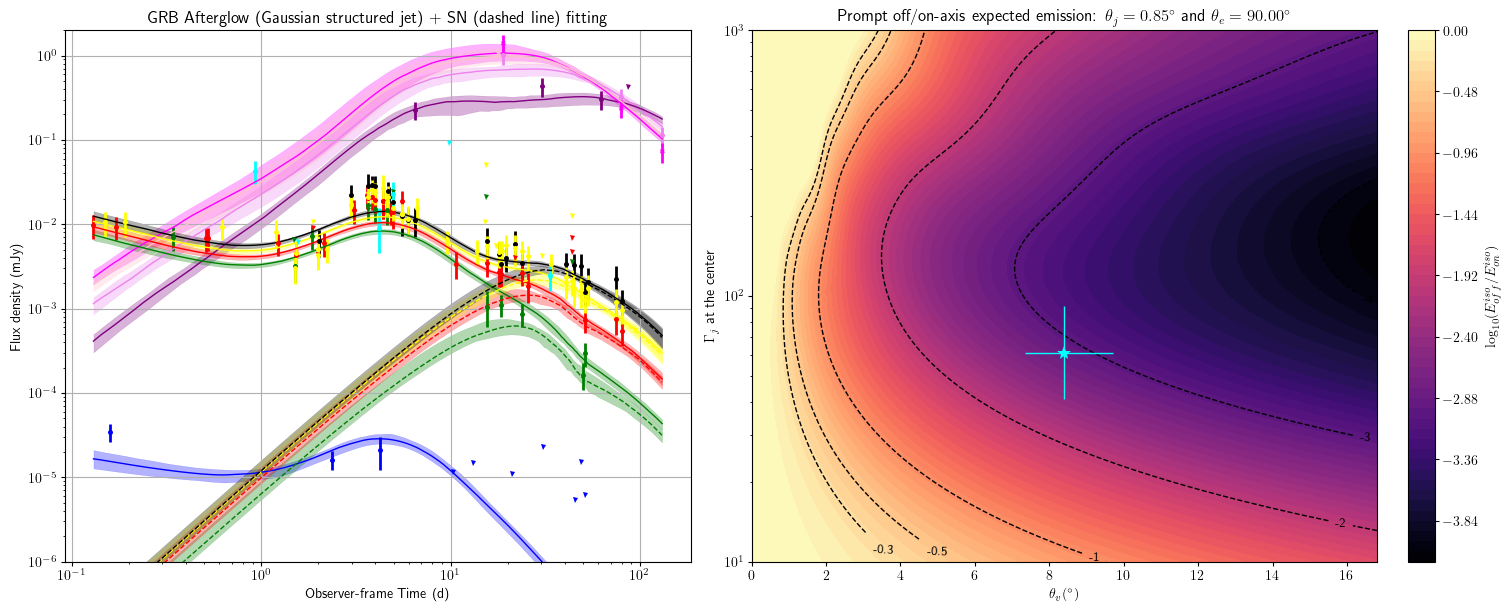

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [8]:
fig2, (ax1,ax2) = plt.subplots(1, 2, figsize=(15, 6), layout="constrained")
#Data points:
#g band
ax1.errorbar(Optical['Since-Trigger-Observed(s)'].value[gind]*stod, 1e-3*Optical['Flux-Density(micro-Jankys)'].value[gind], yerr=np.vstack([np.hypot(1e-3*Optical['Flux-Density_e(micro-Jankys)'].value[gind],  f_relOPT*1e-3*Optical['Flux-Density(micro-Jankys)'].value[gind]), np.hypot(1e-3*Optical['Flux-Density_E(micro-Jankys)'].value[gind], f_relOPT*1e-3*Optical['Flux-Density(micro-Jankys)'].value[gind])]), fmt='o', capsize=5, elinewidth=2 ,label= 'g Data', color='green')
ax1.errorbar(Optical['Since-Trigger-Observed(s)'].value[gUBind]*stod, 1e-3*Optical['Flux-Density(micro-Jankys)'].value[gUBind], fmt='v', capsize=5, elinewidth=2, color='green')
#z band
ax1.errorbar(Optical['Since-Trigger-Observed(s)'].value[zind]*stod, 1e-3*Optical['Flux-Density(micro-Jankys)'].value[zind], yerr=np.vstack([np.hypot(1e-3*Optical['Flux-Density_e(micro-Jankys)'].value[zind],  f_relOPT*1e-3*Optical['Flux-Density(micro-Jankys)'].value[zind]), np.hypot(1e-3*Optical['Flux-Density_E(micro-Jankys)'].value[zind], f_relOPT*1e-3*Optical['Flux-Density(micro-Jankys)'].value[zind])]), fmt='o', capsize=5, elinewidth=2 ,label= 'z Data', color='black')
#r band
ax1.errorbar(Optical['Since-Trigger-Observed(s)'].value[rind]*stod, 1e-3*Optical['Flux-Density(micro-Jankys)'].value[rind], yerr=np.vstack([np.hypot(1e-3*Optical['Flux-Density_e(micro-Jankys)'].value[rind],  f_relOPT*1e-3*Optical['Flux-Density(micro-Jankys)'].value[rind]), np.hypot(1e-3*Optical['Flux-Density_E(micro-Jankys)'].value[rind], f_relOPT*1e-3*Optical['Flux-Density(micro-Jankys)'].value[rind])]), fmt='o', capsize=5, elinewidth=2 ,label= 'r Data', color='red')
ax1.errorbar(Optical['Since-Trigger-Observed(s)'].value[rUBind]*stod, 1e-3*Optical['Flux-Density(micro-Jankys)'].value[rUBind], fmt='v', capsize=5, elinewidth=2, color='red')
#i band
ax1.errorbar(Optical['Since-Trigger-Observed(s)'].value[iind]*stod,  1e-3*Optical['Flux-Density(micro-Jankys)'].value[iind], yerr=np.vstack([np.hypot(1e-3*Optical['Flux-Density_e(micro-Jankys)'].value[iind],  f_relOPT*1e-3*Optical['Flux-Density(micro-Jankys)'].value[iind]), np.hypot(1e-3*Optical['Flux-Density_E(micro-Jankys)'].value[iind], f_relOPT*1e-3*Optical['Flux-Density(micro-Jankys)'].value[iind])]), fmt='o', capsize=5, elinewidth=2 ,label= 'i Data', color='yellow')
ax1.errorbar(Optical['Since-Trigger-Observed(s)'].value[iUBind]*stod, 1e-3*Optical['Flux-Density(micro-Jankys)'].value[iUBind], fmt='v', capsize=5, elinewidth=2, color='yellow')

#IRUV data:
ax1.errorbar(IRUV['Since-Trigger-Observed (s)'].value[IRUVDet]*stod,  1e-3*IRUV['Flux-Density(micro-Jankys)'].value[IRUVDet], yerr=np.vstack([np.hypot(1e-3*IRUV['Flux-Density_e(micro-Jankys)'].value[IRUVDet],  f_relOPT*1e-3*IRUV['Flux-Density(micro-Jankys)'].value[IRUVDet]), np.hypot(1e-3*IRUV['Flux-Density_E(micro-Jankys)'].value[IRUVDet], f_relOPT*1e-3*IRUV['Flux-Density(micro-Jankys)'].value[IRUVDet])]), fmt='o', capsize=5, elinewidth=2 ,label= 'Infrared/Ultraviolet Data', color='cyan')
ax1.errorbar(IRUV['Since-Trigger-Observed (s)'].value[~IRUVDet]*stod, 1e-3*IRUV['Flux-Density(micro-Jankys)'].value[~IRUVDet], fmt='v', capsize=5, elinewidth=2, color='cyan')

#Radio band
#3GHz
ax1.errorbar(Radio['Since-Trigger-Observed(s)'].value[GHz3Dat]*stod,1e-3*Radio['Flux-Density-(micro-Jankys)'].value[GHz3Dat], yerr=np.hypot(1e-3*Radio['Flux-Density-error-(micro-Jankys)'].value[GHz3Dat], f_relRAD*1e-3*Radio['Flux-Density-(micro-Jankys)'].value[GHz3Dat]), fmt='o', capsize=5, elinewidth=2 ,label= 'Radio [3GHz] Data', color='purple')
ax1.errorbar(Radio['Since-Trigger-Observed(s)'].value[GHz3UB]*stod, 1e-3*Radio['Flux-Density-(micro-Jankys)'].value[GHz3UB], fmt='v', capsize=5, elinewidth=2, color='purple')
#5.5GHz
ax1.errorbar(Radio['Since-Trigger-Observed(s)'].value[GHz5Dat]*stod,1e-3*Radio['Flux-Density-(micro-Jankys)'].value[GHz5Dat], yerr=np.hypot(1e-3*Radio['Flux-Density-error-(micro-Jankys)'].value[GHz5Dat], f_relRAD*1e-3*Radio['Flux-Density-(micro-Jankys)'].value[GHz5Dat]), fmt='o', capsize=5, elinewidth=2 ,label= 'Radio [5.5GHz] Data', color='violet')

#9GHz
ax1.errorbar(Radio['Since-Trigger-Observed(s)'].value[GHz9Dat]*stod,1e-3*Radio['Flux-Density-(micro-Jankys)'].value[GHz9Dat], yerr=np.hypot(1e-3*Radio['Flux-Density-error-(micro-Jankys)'].value[GHz9Dat], f_relRAD*1e-3*Radio['Flux-Density-(micro-Jankys)'].value[GHz9Dat]), fmt='X', capsize=5, elinewidth=2 ,label= 'Radio [9GHz] Data', color='magenta')

#8GHz
ax1.errorbar(Radio['Since-Trigger-Observed(s)'].value[GHz8UB]*stod,1e-3*Radio['Flux-Density-(micro-Jankys)'].value[GHz8UB], fmt='v', capsize=5, elinewidth=2 ,label= 'Radio [8GHz] Data', color='pink')

#Xrays
ax1.errorbar(Xray['Since-Trigger-Observed(s)'].value[3:][XRAYDat]*stod,  1e-3*Xray['Flux-Density(micro-Jankys)'].value[3:][XRAYDat], yerr=np.vstack([1e-3*Xray['Flux-Density_e(micro-Jankys)'].value[3:][XRAYDat],1e-3*Xray['Flux-Density_E(micro-Jankys)'].value[3:][XRAYDat]]), fmt='o', capsize=5, elinewidth=2 ,label= 'Xray [1keV] Data', color='blue')
ax1.errorbar(Xray['Since-Trigger-Observed(s)'].value[3:][~XRAYDat]*stod, 1e-3*Xray['Flux-Density(micro-Jankys)'].value[3:][~XRAYDat], fmt='v', capsize=5, elinewidth=2, color='blue')

#Different regions:
# ax1.axvspan(TimesObservedSorted[0], 1.75, color="gold", alpha=0.3)
# ax1.axvspan(1.75, 8, color="gold", alpha=0.3)
# ax1.axvspan(8, TimesObservedSorted[-1], color="gold", alpha=0.3)


#Fitting curves with 1σ band:

#Radio bands:
ax1.plot(t_grid, p505R, color="violet", label=rf"model Radio [5.5GHz] ($1\sigma$)")
ax1.fill_between(t_grid, p165R, p845R, color="violet", alpha=0.3)

ax1.plot(t_grid, p503R, color="purple", label=rf"model Radio [3GHz] ($1\sigma$)")
ax1.fill_between(t_grid, p163R, p843R, color="purple", alpha=0.3)

ax1.plot(t_grid, p509R, color="magenta", label=rf"model Radio [9GHz] ($1\sigma$)")
ax1.fill_between(t_grid, p169R, p849R, color="magenta", alpha=0.3)

ax1.plot(t_grid, p508R, color="pink", label=rf"model Radio [8GHz] ($1\sigma$)")
ax1.fill_between(t_grid, p168R, p848R, color="pink", alpha=0.3)

ax1.plot(t_grid, p503RSN, color="purple", linestyle='--')
ax1.fill_between(t_grid, p163RSN, p843RSN, color="purple", alpha=0.3)

ax1.plot(t_grid, p505RSN, color="violet", linestyle='--')
ax1.fill_between(t_grid, p165RSN, p845RSN, color="violet", alpha=0.3)

ax1.plot(t_grid, p509RSN, color="magenta", linestyle='--')
ax1.fill_between(t_grid,p169RSN,p849RSN,color='magenta',alpha=0.3)

ax1.plot(t_grid,p508RSN,color='pink',linestyle='--')
ax1.fill_between(t_grid,p168RSN,p848RSN,color='pink',alpha=0.3)

#X-ray band:
ax1.plot(t_grid, p50XSN ,color='blue', linestyle='--')
ax1.fill_between(t_grid,p16XSN,p84XSN,color='blue',alpha=0.3)

ax1.plot(t_grid,p50X,color='blue',label=rf"model X-ray [1keV] ($1\sigma$)")
ax1.fill_between(t_grid,p16X,p84X,color='blue',alpha=0.3)

#Optical bands:
ax1.plot(t_grid,p50gSN,color='green', linestyle='--')
ax1.fill_between(t_grid,p16gSN,p84gSN,color='green',alpha=0.3)

ax1.plot(t_grid,p50g,color='green',label=rf"model g ($1\sigma$)")
ax1.fill_between(t_grid,p16g,p84g,color='green',alpha=0.3)

ax1.plot(t_grid, p50r, color="red", label=rf"model r ($1\sigma$)")
ax1.fill_between(t_grid, p16r, p84r, color="red", alpha=0.3)

ax1.plot(t_grid, p50rSN, color="red", linestyle='--')
ax1.fill_between(t_grid, p16rSN, p84rSN, color="red", alpha=0.3)

ax1.plot(t_grid, p50i, color="yellow", label=rf"model i ($1\sigma$)")
ax1.fill_between(t_grid, p16i, p84i, color="yellow", alpha=0.3)

ax1.plot(t_grid, p50iSN, color="yellow", linestyle='--')
ax1.fill_between(t_grid, p16iSN, p84iSN, color="yellow", alpha=0.3)

ax1.plot(t_grid, p50z, color="black", label=rf"model z ($1\sigma$)")
ax1.fill_between(t_grid, p16z, p84z, color="black", alpha=0.3)

ax1.plot(t_grid, p50zSN, color="black", linestyle='--')
ax1.fill_between(t_grid, p16zSN, p84zSN, color="black", alpha=0.3)

# ax1.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
ax1.set_xscale('log')
ax1.set_yscale('log')
# ax.set_xlim(10, TimesObservedSorted[-1])
ax1.set_ylim(1e-6, 2)
ax1.grid()
ax1.set_ylabel('Flux density (mJy)')
ax1.set_xlabel('Observer-frame Time (d)')
# ax1.set_title(rf'Afterglow (Gaussian with VegasAfterglow) + SN (dashed line, Arnett model) fitting of the data. LogZ = {ready_final_model.log_evidence:.2f} $\pm$ {ready_final_model.log_evidence_err:.2f}')
ax1.set_title(rf'GRB Afterglow (Gaussian structured jet) + SN (dashed line) fitting')



#Now, for the prompt plot: 
cs = ax2.contourf(VVALM, GammaVM, EisoRat, levels=60, cmap=mpl.colormaps['magma'])
# overlay a contour line at log10(ratio) = -5
# style arrays sized to the number of levels
cs_lines=ax2.contour(VVALM, GammaVM, EisoRat_masked,
                     levels=levels_to_mark,
                     colors='black', linewidths=1.0, linestyles='--')
# build labels for each level and put them on the contours
fmt = {lvl: rf'{lvl}' for lvl in levels_to_mark}
ax2.clabel(cs_lines, fmt=fmt, inline=True, fontsize=9)
ax2.errorbar(np.rad2deg(q_final.loc['thv', 'P50']), q_final.loc['g0', 'P50'], xerr=np.vstack([np.rad2deg(q_final.loc['thv', 'P50'])-np.rad2deg(q_final.loc['thv', 'P16']), np.rad2deg(q_final.loc['thv', 'P84'])-np.rad2deg(q_final.loc['thv', 'P50'])]), yerr=np.vstack([q_final.loc['g0', 'P50']-q_final.loc['g0', 'P16'], q_final.loc['g0', 'P84']-q_final.loc['g0', 'P50']]), fmt='*', c='cyan', markersize=10)
ax2.set_xlabel(r'$\theta_v (^{\circ})$')
ax2.set_ylabel(r'$\Gamma_j$ at the center')
ax2.set_title(rf'Prompt off/on-axis expected emission: $\theta_j = {thetajet:.2f}^\circ$ and $\theta _e= {thetaedge:.2f}^\circ$')
ax2.set_yscale('log')
fig2.colorbar(cs, label=r'$\log_{10}(E^{iso}_{off} / E^{iso}_{on})$')
ax2.set_ylim(GammaVal.min(), GammaVal.max())
ax2.set_xlim(VVAL.min(), VVAL.max())

plt.show()
plt.close(fig2)

# #For this choice of parameters the Eiso that would be emitted on axis would be given by:
# EisoRatchoice=EisoRatInterp([[np.log10(g0), thetajet*thvdthc]])[0] #To extract the scalar the function has interpolated
# #Now, this would be the ratio of energies in logarithmic scale, to go from there to the Eiso on axis:
# EisoOffAxis=(10**EisoRatchoice)*EisofromEff(effi,10**loge0) #Notice that this is approximated since we are interpolating

display(Math(rf"\text{{For the inferred jet parameters of the afterglow:}}"),
        Math(rf"\Gamma_0 = {q_final.loc['g0', 'P50']:.2f}^{{+{q_final.loc['g0', 'P84'] - q_final.loc['g0', 'P50']:.2f}}}_{{-{q_final.loc['g0', 'P50'] - q_final.loc['g0', 'P16']:.2f}}},"), 
        Math(rf"\\log_{{10}}(E_{{k, 0}}/\mathrm{{erg}}) = {q_final.loc['loge0', 'P50']:.2f}^{{+{q_final.loc['loge0', 'P84'] - q_final.loc['loge0', 'P50']:.2f}}}_{{-{q_final.loc['loge0', 'P50'] - q_final.loc['loge0', 'P16']:.2f}}},"),
        Math(rf" \theta_v = ({np.rad2deg(q_final.loc['thv', 'P50']):.2f}^{{+{np.rad2deg(q_final.loc['thv', 'P84']) - np.rad2deg(q_final.loc['thv', 'P50']):.2f}}}_{{-{np.rad2deg(q_final.loc['thv', 'P50']) - np.rad2deg(q_final.loc['thv', 'P16']):.2f}}})^\circ,"),
        Math(rf" \theta_c = ({np.rad2deg(q_final.loc['thc', 'P50']):.2f}^{{+{np.rad2deg(q_final.loc['thc', 'P84']) - np.rad2deg(q_final.loc['thc', 'P50']):.2f}}}_{{-{np.rad2deg(q_final.loc['thc', 'P50']) - np.rad2deg(q_final.loc['thc', 'P16']):.2f}}})^\circ;"))
display(Math(rf"\text{{which translates into an off-axis ratio of: }} \theta_v / \theta_c = {thv_med/thc_med:.2f}^{{+{ratio_E:.2f}}} _{{-{ratio_e:.2f}}}."))



# Now, to know the effect of this ratio in the prompt emission, we can use the contour plot to know the value of the 
# ratio of Eiso off and on axis for this particular combination of parameters. However, there is no a linear 
# relation between gamma, thetav and Eiso ratio, so we need to interpolate in the contour plot and 
# deal with the distribution of the paramters extracted from the posterior of the fitting. To do so, 
# we can use the function defined above to interpolate the contour plot and the posterior distribution already stored.

#For the computations with percentiles:
def pct(arr, p):
        return np.percentile(arr, p)

#Extracting the samples of the parameters from the posterior distribution:
ThetaVSamples=np.rad2deg(posterior_final_model['thv'].values)
GammaSamples=posterior_final_model['g0'].values


#Interpolating the contour plot for each of the samples:
CombinedSamples=np.column_stack([GammaSamples,ThetaVSamples])
#We do this because the posterior results are correlated from the Bayesian parameter inference,
#this is; F(Gamma_i, Theta_v_i) no F(Gamma_i, Theta_v_j), which breaks correlations from the 
#posterior distribution.


#So:
EisoRatSamples=EisoRatInterp(CombinedSamples)
EisoRatMean=pct(EisoRatSamples, 50)
EisoRatPlus=pct(EisoRatSamples, 84) - pct(EisoRatSamples, 50)
EisoRatMinus=pct(EisoRatSamples, 50) - pct(EisoRatSamples, 16)

#Measured Eiso from the prompt emission:
EisoOffDist=sample_split_normal(Eiso.value, Eiso_e.value, Eiso_E.value, size=len(GammaSamples))
EisoOnDist=EisoOffDist/(10**EisoRatSamples)
EisoOnMean=pct(EisoOnDist, 50)
EisoOnPlus=pct(EisoOnDist, 84) - pct(EisoOnDist, 50)
EisoOnMinus=pct(EisoOnDist, 50) - pct(EisoOnDist, 16)

#To print the results:
EisooffMan, EisooffExp = sci_notation(Eiso.value)
EisoOnMan, EisoOnExp = sci_notation(EisoOnMean)

display(Math(rf"\text{{Being off-axis will have a mitigation effect in the prompt emission equal to:}} " ),
        Math(rf"\log_{{10}}(E_{{\text{{iso,off}}}}/E_{{\text{{iso,on}}}})={EisoRatMean:.2f}^{{+{EisoRatPlus:.2f}}}_{{-{EisoRatMinus:.2f}}}" )
)
display(Math(rf"\text{{This, translates an observed prompt emission of (in X-rays):}} " ),
        Math(rf"E_{{\text{{iso, off}}}}={EisooffMan:.2f}^{{+{(Eiso_E.value/10**EisooffExp):.2f}}}_{{-{(Eiso_e.value/10**EisooffExp):.2f}}} \times 10^{{{EisooffExp}}} \text{{ erg}}" ),
                Math(rf"\text{{into an on-axis equivalent of:}} " ),
                Math(rf"E_{{\text{{iso,on}}}}={EisoOnMan:.2f}^{{+{(EisoOnPlus/10**EisoOnExp):.2f}}}_{{-{(EisoOnMinus/10**EisoOnExp):.2f}}} \times 10^{{{EisoOnExp}}} \text{{ erg}}" )
)

# Deriving a value for efficiency or Eiso on-axis:

In [9]:
#Definition of the radiative efficiency:
def EisofromEff(Eff,Ekin):
    return Eff*Ekin/(1-Eff)

# Now, the parameter that will stablish a connection between the prompt emission and the 
# afterglow emission will be the GRB/FXT radiative efficiency, defined as: E_prompt_iso/(E_prompt_iso + E_K_iso)
# COMMENT: NOTICE THAT E_prompt_iso IS FREQUENCY DEPENDENT AND E_K_iso IS NOT (IT IS A PROPERTY OF THE JET)
# SO THE DIFFERENCE BETWEEN GRB AND FXT RADIATIVE EFFICIENCY IS THAT: FOR GRBs E_prompt_iso IS IN GAMMA RAYS
# AND FOR FXTs IT IS IN X-RAYS.

# In this definition of the radiative efficiency, the kinetic energy is related to the isotropic equivalent energy from the prompt
# emission. This is, what portion of the total kinetic energy of the jet went to the prompt emission.

#Finally, to compute the radiative efficiency from the results obtained from the modeling:
def RadEff(Eisoon, Ekin):
    return Eisoon/(Eisoon + Ekin)

Ekin=10**posterior_final_model['loge0'].values

#Then:
RadEffDist=RadEff(EisoOnDist, Ekin)
#In percentage for the display:
RadEffMean=pct(RadEffDist, 50)*100
RadEffPlus=(pct(RadEffDist, 84) - pct(RadEffDist, 50))*100
RadEffMinus=(pct(RadEffDist, 50) - pct(RadEffDist, 16))*100
display(Math(rf"\text{{The radiative efficiency of the event (in X-rays for EP240414a), defined as }} \eta = E_{{iso,on}}/(E_{{iso,on}} + E_k) \text{{ is:}}" ),
        Math(rf"\eta = {RadEffMean:.2f}^{{+{RadEffPlus:.2f}}}_{{-{RadEffMinus:.2f}}} \, \%" )
)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

# Studying the environment of the event in detail:

In [10]:
#Using the same definition of the environment mass density as the one used in VegasAfterglow codes:
def VegasAfterglowDensity(A_star, nISM, n0,r):
    A=A_star*5e11 #g/cm
    rhoISM=nISM*const.m_p.value*1e3 #g/cm^3
    r02=A/(n0*1.3*const.m_p.value*1e3) #cm^2
    return (A/(r**2 + r02)) +rhoISM

def WindIsmTransitionRadius(A_star, nISM):
    A=A_star*5e11 #g/cm
    rhoISM=nISM*const.m_p.value*1e3 #g/cm^3
    return np.sqrt(A/rhoISM) #In cm

#Now, using the results from the fitting:
A_star_samples=10**posterior_final_model['loga'].values
nISM_samples=10**posterior_final_model['lognism'].values


TransitionRadiusSamples=WindIsmTransitionRadius(A_star_samples, nISM_samples) 
#The line above is right because the posterior distributions are correlated (see explanation above)
TransitionRadiusMean=np.percentile(TransitionRadiusSamples, 50)
TransitionRadiusPlus=np.percentile(TransitionRadiusSamples, 84) - np.percentile(TransitionRadiusSamples, 50)
TransitionRadiusMinus=np.percentile(TransitionRadiusSamples, 50) - np.percentile(TransitionRadiusSamples, 16)

TransRMan, TransRExp = sci_notation(TransitionRadiusMean)


display(Math(rf"\text{{The transition radius between the wind and ISM environments, defined as }} R_{{\text{{transition}}}} = \sqrt{{A / \rho_{{ISM}}}} \text{{ is:}}" ),
        Math(rf"R_{{\text{{transition}}}} = ({TransRMan:.2f}^{{+ {(TransitionRadiusPlus/10**TransRExp):.2f}}}_{{-{TransitionRadiusMinus/10**TransRExp:.2f}}} \times 10^{{{TransRExp}}}) \text{{ cm}}" )
)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

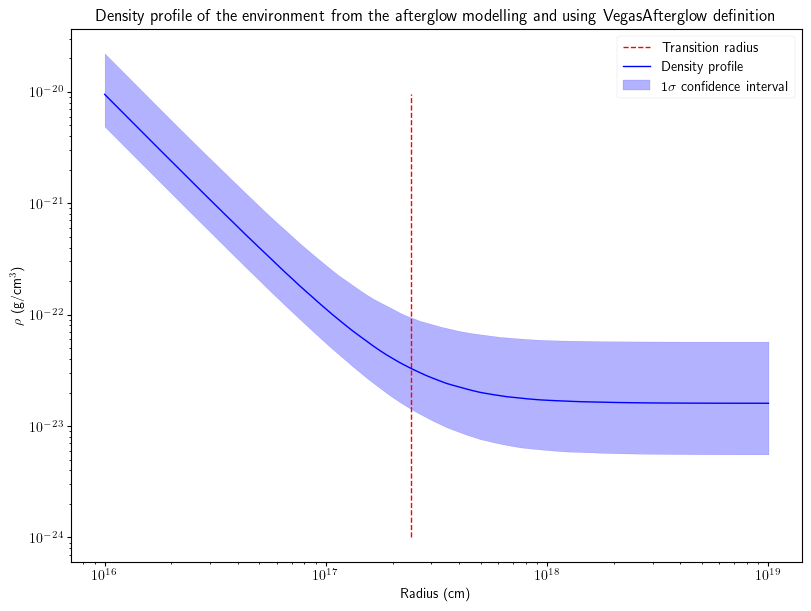

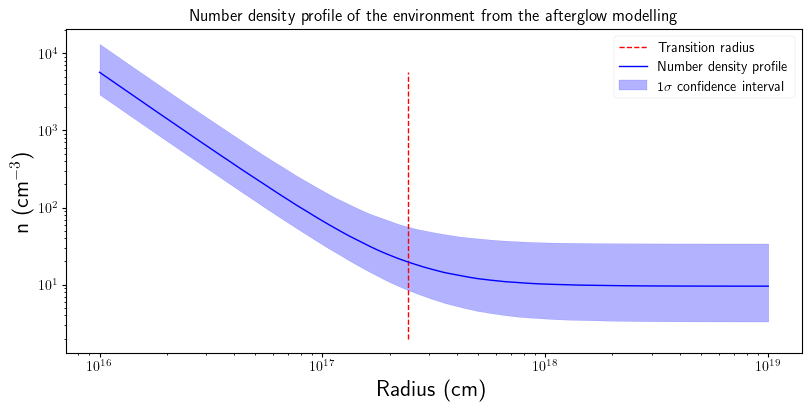

In [11]:
#Now, plotting the mass density function for our fitting:
r_plot=np.logspace(16, 19, 100) #cm

#To compute the density profile over all the samples from the posterior distribution:
A_grid = A_star_samples[:, None]          # (Ndist, 1)
nISM_grid = nISM_samples[:, None]    # (Ndist, 1) This shape because the posterior distributions are correlated.
r_grid = r_plot[None, :]             # (1, Nr)

#So, density grid with shape (Na, Nn, Nr):
DensityGrid = VegasAfterglowDensity(A_grid, nISM_grid, np.inf, r_grid)
DensityPlotMean=np.percentile(DensityGrid, 50, axis=(0))
DensityPlotPlus=np.percentile(DensityGrid, 84, axis=(0)) - np.percentile(DensityGrid, 50, axis=(0))
DensityPlotMinus=np.percentile(DensityGrid, 50, axis=(0)) - np.percentile(DensityGrid, 16, axis=(0))


#In mass density units of g/cm^3:
fig3, ax3 = plt.subplots(figsize=(8, 6), layout="constrained")
ax3.vlines(TransitionRadiusMean, ymin=1e-24, ymax=DensityPlotMean.max(), color='red', linestyle='--', label=rf"Transition radius")
ax3.plot(r_plot, DensityPlotMean, color='blue', label='Density profile')
ax3.fill_between(r_plot, DensityPlotMean - DensityPlotMinus, DensityPlotMean + DensityPlotPlus, color='blue', alpha=0.3, label=r'1$\sigma$ confidence interval')
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_xlabel('Radius (cm)')
ax3.set_ylabel(r'$\rho$ (g/cm$^3$)')
ax3.set_title('Density profile of the environment from the afterglow modelling and using VegasAfterglow definition')
ax3.legend()
plt.show()
plt.close(fig3)

#In number density units:
fig4, ax4 = plt.subplots(figsize=(8, 4), layout="constrained")
ax4.vlines(TransitionRadiusMean, ymin=2, ymax=(DensityPlotMean/(const.m_p.value*1e3)).max(), color='red', linestyle='--', label=rf"Transition radius")
ax4.plot(r_plot, DensityPlotMean/(const.m_p.value*1e3), color='blue', label='Number density profile')
ax4.fill_between(r_plot, DensityPlotMean/(const.m_p.value*1e3) - DensityPlotMinus/(const.m_p.value*1e3), DensityPlotMean/(const.m_p.value*1e3) + DensityPlotPlus/(const.m_p.value*1e3), color='blue', alpha=0.3, label=r'1$\sigma$ confidence interval')
ax4.set_xscale('log')
ax4.set_yscale('log')
ax4.set_xlabel('Radius (cm)', fontsize=16)
ax4.set_ylabel(r'n (cm$^{-3}$)', fontsize=16)
ax4.set_title('Number density profile of the environment from the afterglow modelling')
ax4.legend()
plt.show()
plt.close(fig4)

# For the Mass of nickel from the inferred parameters:

In [12]:
# From Anderson 2019, the median of the mass of Nickel observed is around 0.369 Msun for SN Type Ic-BL, so:
NickelMassMean=0.369 #Msun
NickelMassSTD=0.410 #Msun

#Then, from the fitting results:
NickelMassSamples=posterior_final_model['f_nickel'].values*posterior_final_model['mej'].values
NickelMassMean=np.percentile(NickelMassSamples, 50)
NickelMassPlus=np.percentile(NickelMassSamples, 84) - np.percentile(NickelMassSamples, 50)
NickelMassMinus=np.percentile(NickelMassSamples, 50) - np.percentile(NickelMassSamples, 16)

display(Math(rf"\text{{The mass of Nickel synthesized in the SN associated with the event, defined as }} M_{{\text{{Ni}}}} = f_{{\text{{Ni}}}} \cdot M_{{\text{{ej}}}} \text{{ is:}}" ),
        Math(rf"M_{{\text{{Ni}}}} = {NickelMassMean:.2f}^{{+{NickelMassPlus:.2f}}}_{{-{NickelMassMinus:.2f}}} \, M_\odot" )
)
display(Math(rf"\text{{This is consistent with the median mass of Nickel observed in SN Type Ic-BL, which is around }} 0.369 \, M_\odot \text{{ (Anderson 2019)}}."))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

# Studying the on-axis corrections for the prompt emission and the interpretation of EP240414a in the overall GRB picture:

## Firsty, to study the prompt emission correted for the on-axis case and compare it to other GRBs, we have extend the computation of Eiso to the gamma-ray band.

In [13]:
#Firstly, extracting the data from the prompt emission:
#In this case, Sun et al. provided the prompt emission data from WXT divided in three different time intervals,
# so we will use for this analysis the average normalization constant in the X-ray band and use the best fitting model
# to extrapolate Eiso to the 10-1000 keV band, which is the one used for the definition of Eiso in GRBs. 
# so:

SunetalIntegratedFluxtxt='/data/egonzalezramos/EP240414a Data from different articles/Sun et al Unabsorbed Fluxes.txt'
SunetalIntegratedFlux=Table.read(SunetalIntegratedFluxtxt, format="ascii", comment="#")
Nsamples=len(Ekin) #To use the same number of samples as the posterior distribution of the afterglow fitting,
                    #to be able to propagate the uncertainties in a consistent way.
PromptIntegratedFlux=SunetalIntegratedFlux['UnabsFlux(ergcm-2s-1)'][0:3].data*(u.erg/((u.cm**2)*u.s))
PromptFluxes_e=SunetalIntegratedFlux['UnabsFlux_e(ergcm-2s-1)'][0:3].data*(u.erg/((u.cm**2)*u.s))
PromptFluxes_E=SunetalIntegratedFlux['UnabsFlux_E(ergcm-2s-1)'][0:3].data*(u.erg/((u.cm**2)*u.s))
T_start=SunetalIntegratedFlux['t_obs_start(s)'][0:3].data*u.s
T_end=SunetalIntegratedFlux['t_obs_final(s)'][0:3].data*u.s

#From Sun et al. article:
T90=155
T90_e=22
T90_E=64
T90Dist=sample_split_normal(T90, T90_e, T90_E, size=Nsamples)

#Averaging between all three of them:
PromptFluxDist=[]
for i in range(len(PromptIntegratedFlux)):
    PromptFluxDist.append(sample_split_normal(PromptIntegratedFlux[i].value, PromptFluxes_e[i].value, PromptFluxes_E[i].value, size=Nsamples))
MeanDist=np.mean(PromptFluxDist, axis=0)
PromptMean=np.percentile(MeanDist, 50)
PromptPlus=np.percentile(MeanDist, 84) - np.percentile(MeanDist, 50)
PromptMinus=np.percentile(MeanDist, 50) - np.percentile(MeanDist, 16)

#So, using the best fit Power Law model to compute the normalization factor of the power law:
alphabest=-3.1
alphabest_e=0.8
alphabest_E=0.7

#Using the function derived in the Data Analyser Notebook:
def propagate_to_KExt(F, F_e, F_E,
                   alpha, alpha_e, alpha_E,
                   E1, E2, Eext1, Eext2, Ndraw=200000, return_samples=False):
    #Some conditions to check for the inputs
    if F <= 0:
        raise ValueError("Unabsorbed flux must be positive.")
    #Now, let's define the distributions of points for the flux and photon index inputs,
    #to apply Monte-Carlo techniques
    Fv = sample_split_normal(F, F_e, F_E, Ndraw)
    alp = sample_split_normal(alpha, alpha_e, alpha_E, Ndraw)
    #Creating our empty variable for the computation of samples of the normalization constant
    if Fv.size==1:
        K_samples = np.empty_like(alp)
    else:
        K_samples = np.empty_like(Fv)

    #To handle with the special case of the photon index being equal to -2
    mask_not2 = np.abs(alp + 2.0) > 1e-8

    if mask_not2.any():
        #values of alpha different from -2
        AG = alp[mask_not2]
        #integral term:
        integral = (E2**(2.0 + AG) - E1**(2.0 + AG)) / (2.0 + AG)
        #and for the K value:
        K_samples[mask_not2] = Fv[mask_not2] / (CkeV * integral)
    #Now, the same but for the case of alpha = -2
    if (~mask_not2).any():
        integral2 = np.log(E2 / E1)
        K_samples[~mask_not2] = Fv[~mask_not2] / (CkeV * integral2)

    #Extending the integral:
    Finteg = np.empty_like(K_samples)
    print(len(K_samples), len(Fv), len(alp), len(Finteg))
    if mask_not2.any():
        #values of alpha different from -2
        AG = alp[mask_not2]
        #integral term:
        integral = (Eext2**(2.0 + AG) - Eext1**(2.0 + AG)) / (2.0 + AG)
        #and for F value:
        Finteg[mask_not2] = K_samples[mask_not2] * (CkeV * integral)
        #Now, the same but for the case of alpha = -2
    if (~mask_not2).any():
        integral2 = np.log(Eext2 / Eext1)
        Finteg[~mask_not2] = K_samples[~mask_not2] * (CkeV * integral2)


    #To handle with possible non-physical values of the normalization (negative or zero values)
    #Substituting those negative or zero values by the smallest positive value of the sample. 
    #This is a way (practical but not rigurous) of solving this non-physical errors that should not occur.
    #n_negK = np.sum(K_samples <= 0)
    #if n_negK > 0:
    #    K_samples[K_samples <= 0] = np.nextafter(0, 1.0)

    def pct(arr, p):
        return np.percentile(arr, p)

    #Finally, defining the outputs.
    result = {
        'K_median': float(pct(K_samples, 50)),
        'K_16': float(pct(K_samples, 16)),
        'K_84': float(pct(K_samples, 84)),
        'K_05': float(pct(K_samples, 5)),
        'K_95': float(pct(K_samples, 95)),
        'n_draws': Ndraw,
        #'n_negK_replaced': int(n_negK),
    }
    if return_samples:
        result['K_samples'] = K_samples
        result['F_samples'] = Fv
        result['Alpha_samples'] = alp
        result['Fint_Extended'] = Finteg
    return result

#And to obtain the flux per Hz at an specific frequency:
def K_to_Fnu(K, alpha, nu):
    return K * (hPlanck**(2.0 + alpha)) * (CkeV**(-alpha - 1.0)) * (nu**(1.0 + alpha))


#Now, using the function to propagate the flux and photon index uncertainties to the normalization constant K:
propagation_result = propagate_to_KExt(PromptMean, PromptMinus, PromptPlus, alphabest, alphabest_e, alphabest_E, 0.5, 4, 10, 1000, Nsamples, return_samples=True) 
#Integrating in the 0.5-4 keV band, which is the one used for the definition of Eiso in FXTs.
Kint=propagation_result['K_samples']
alphaint=propagation_result['Alpha_samples']
Finteg=propagation_result['Fint_Extended']

#So, the integrated flux inside the 10-1000 keV band is given by Finteg:
FintegMean=np.percentile(Finteg, 50)
FintegPlus=np.percentile(Finteg, 84) - np.percentile(Finteg, 50)
FintegMinus=np.percentile(Finteg, 50) - np.percentile(Finteg, 16)
FintegMan, FintegExp = sci_notation(FintegMean)


#And calculating the isotropic equivalent energy in the 10-1000 keV band:
#Conversion from Mpc to cm:
MpctoCM=3.08567758128e+24
#Assuming standard LambdaCDM cosmology.
from astropy.cosmology import Planck18 as cosmo
def ftol(redshift,flux):
    return 4*np.pi*(((cosmo.luminosity_distance(redshift).value)*(MpctoCM))**2)*flux
#with the K-correction:
def ftolK(redshift,flux,photonindex):
    return 4*np.pi*(((cosmo.luminosity_distance(redshift).value)*(MpctoCM))**2)*flux*(1+z)**(-photonindex-2)

#Luminosity to flux conversion with K-correction:
def LtoFK(redshift,luminosity,photonindex):
    return luminosity/(4*np.pi*(((cosmo.luminosity_distance(redshift).value)*(MpctoCM))**2)*(1+z)**(-photonindex-2))

#Luminosity to flux conversion without K-correction:
def LtoF(redshift,luminosity):
    return luminosity/(4*np.pi*(((cosmo.luminosity_distance(redshift).value)*(MpctoCM))**2))

EisoDist=ftol(sample_split_normal(z,ez,ez,size=Nsamples), Finteg)*T90Dist #In erg
EisoMean=np.percentile(EisoDist, 50)
EisoPlus=np.percentile(EisoDist, 84) - np.percentile(EisoDist, 50)
EisoMinus=np.percentile(EisoDist, 50) - np.percentile(EisoDist, 16)
EisoMan, EisoExp = sci_notation(EisoMean)

2228 2228 2228 2228


In [14]:
#Now, using the BPL fit with the average of the flux obtained before and a peak at 1.3keV:
alpha=-1 #Low energy photon index fixed
beta=-2.9 #High energy photon index
beta_e=0.9
beta_E=0.6
Epeak=1.3 #1sigma upper limit keV


#Creating another function to calculate K and extend the integral to other regions of the spectrum:
def propagate_to_KBPL(
        F, F_e, F_E,
        alpha, alpha_e, alpha_E,
        beta, beta_e, beta_E,
        E1, E2, Ebreak,
        Eext1, Eext2,
        Ndraw=200000,
        return_samples=False):
    
    # Monte Carlo sampling
    Fv = sample_split_normal(F, F_e, F_E, Ndraw)
    alp = sample_split_normal(alpha, alpha_e, alpha_E, Ndraw)
    bet = sample_split_normal(beta, beta_e, beta_E, Ndraw)

    # valid beta condition
    valid = bet < -2.0
    Fv = Fv[valid]
    alp = alp[valid]
    bet = bet[valid]

    if len(bet) == 0:
        raise ValueError("No valid beta samples")

    # break energy (FIXED INPUT)
    Eb = Ebreak


    integral1 = np.where( alp != -2, (Eb**(alp+2) - E1**(alp+2)) / (alp + 2),np.log(Eb / E1))
    C = Eb**(alp - bet)
    integral2 = np.where(bet != -2,C * (E2**(bet+2) - Eb**(bet+2)) / (bet + 2), C * np.log(E2 / Eb))

    integral = integral1 + integral2
    K_samples = Fv / (CkeV * integral)

    # EXTENSION

    integralext = np.zeros_like(K_samples)
    mask = Eext1 < Eb
    if mask:
        int1 = (Eb**(alp+2) - Eext1**(alp+2)) / (alp + 2)
        Cmask = Eb**(alp - bet)
        int2 = Cmask * ((Eext2**(bet+2) - Eb**(bet+2)) / (bet + 2))
        integralext = int1 + int2
    else:
        Cmask = Eb**(alp - bet)
        integralext = Cmask * ((Eext2**(bet+2) - Eext1**(bet+2)) / (bet + 2))
    FintExt = K_samples * CkeV * integralext

    return {
        "K_samples": K_samples,
        "Beta_samples": bet,
        "Alpha_samples": alp,
        "FintExt_samples": FintExt,
    } if return_samples else {
        "K_median": np.percentile(K_samples, 50),
        "K_16": np.percentile(K_samples, 16),
        "K_84": np.percentile(K_samples, 84),
    }

FextSamplesDist=propagate_to_KBPL(PromptMean, PromptMinus, PromptPlus, alpha, 0, 0, beta, beta_e, beta_E, 0.5, 4, Epeak, 10, 1000, Nsamples, return_samples=True)
FextSamples=FextSamplesDist['FintExt_samples']
FextMean=np.percentile(FextSamples, 50)
FextPlus=np.percentile(FextSamples, 84) - FextMean
FextMinus=FextMean - np.percentile(FextSamples, 16)
FextMan, FextExp = sci_notation(FextMean)




#For Eiso:
NBPLsamples=FextSamples.size
EisoExtDist=ftol(sample_split_normal(z,ez,ez,size=NBPLsamples), FextSamples)*sample_split_normal(T90, T90_e, T90_E, size=NBPLsamples) #In erg. We use beta because in the integrated band the dominating part is the decreasing power law.
EisoExtMean=np.percentile(EisoExtDist, 50)
EisoExtPlus=np.percentile(EisoExtDist, 84) - np.percentile(EisoExtDist, 50)
EisoExtMinus=np.percentile(EisoExtDist, 50) - np.percentile(EisoExtDist, 16)
EisoExtMan, EisoExtExp = sci_notation(EisoExtMean)

In [15]:
#Now, using the Band function with the average of the flux obtained before and a peak at 1.3keV:
#And in this case also assuming that the low energy and high energy photon indeces are equal to the ones
#obtained from the BPL fit, since the Band function is a BPL with an exponential break, 
# so it has the same behaviour as the BPL far away from the break.

#Creating another function to calculate K and extend the integral to other regions of the spectrum:
def propagate_to_Band(
        F, F_e, F_E,
        beta, beta_e, beta_E,
        E1, E2,
        Ep,
        Eext1, Eext2,
        Ndraw=200000,
        return_samples=False):

    """
    Band-function propagation assuming alpha = -1.

    Photon model:

        N(E) = K * E^{-1} * exp(-E/Ep)
                for E < Ebreak

        N(E) = K * Cband * E^{beta}
                for E >= Ebreak

    with

        Ebreak = (-1 - beta) * Ep

    and Ep = Epeak because alpha = -1.
    """
    if F <= 0:
        raise ValueError("Flux must be positive.")

    if beta - beta_e > -2.0:
        raise ValueError(
            "beta must remain below -2 within uncertainties."
        )

    if Ep <= 0:
        raise ValueError("Ep must be positive.")
    
    Fv = sample_split_normal(F, F_e, F_E, Ndraw)
    bet = sample_split_normal(beta, beta_e, beta_E, Ndraw)

    # Reject unphysical beta values
    valid = bet < -2.0

    Fv = Fv[valid]
    bet = bet[valid]

    if len(bet) == 0:
        raise ValueError("No valid samples with beta < -2.")

    # Break energy
    Ebreak = (-1.0 - bet) * Ep

    # LOW-ENERGY integral
    integral1 = Ep * (
        np.exp(-E1 / Ep)
        - np.exp(-Ebreak / Ep)
    )

    # High-energy continuity factor
    Cband = (
        np.exp(bet + 1.0)
        * (Ebreak) ** (-1.0 - bet)
    )

    # HIGH-ENERGY integral

    integral2 = (Cband* (E2 ** (2.0 + bet) - Ebreak ** (2.0 + bet))/ (2.0 + bet))

    integral = integral1 + integral2

    # Normalization samples
    K_samples = Fv / (CkeV * integral)

    # EXTENDED FLUX

    integralext = np.zeros_like(K_samples)

    # Case 1:
    # extension begins below break
    mask_low = Eext1 < Ebreak

    if np.any(mask_low):
        int1 = Ep * (np.exp(-Eext1 / Ep)- np.exp(-Ebreak[mask_low] / Ep))
        int2 = (Cband[mask_low]* (Eext2 ** (2.0 + bet[mask_low])- Ebreak[mask_low] ** (2.0 + bet[mask_low]))/ (2.0 + bet[mask_low]))
        integralext[mask_low] = int1 + int2

    # Case 2:
    # entirely above break
    mask_high = ~mask_low

    if np.any(mask_high):
        integralext[mask_high] = (Cband[mask_high]* (Eext2 ** (2.0 + bet[mask_high])- Eext1 ** (2.0 + bet[mask_high]))/ (2.0 + bet[mask_high]))

    # Extended flux samples
    FintExt = K_samples * (CkeV * integralext)

    # Percentiles

    def pct(arr, p):
        return np.percentile(arr, p)

    result = {
        'K_median': float(pct(K_samples, 50)),
        'K_16': float(pct(K_samples, 16)),
        'K_84': float(pct(K_samples, 84)),
        'K_05': float(pct(K_samples, 5)),
        'K_95': float(pct(K_samples, 95)),
        'n_draws': Ndraw,
        'n_valid': len(K_samples),
        'Fext_median': float(pct(FintExt, 50)),
    }

    if return_samples:
        result['K_samples'] = K_samples
        result['Beta_samples'] = bet
        result['F_samples'] = Fv
        result['FintExt_samples'] = FintExt
        result['Ebreak_samples'] = Ebreak

    return result


FextSamplesDistBand=propagate_to_Band(PromptMean, PromptMinus, PromptPlus, beta, beta_e, beta_E, 0.5, 4, Epeak, 10, 1000, Nsamples, return_samples=True)
FextSamplesBand=FextSamplesDistBand['FintExt_samples']
FextMeanBand=np.percentile(FextSamplesBand, 50)
FextPlusBand=np.percentile(FextSamplesBand, 84) - np.percentile(FextSamplesBand, 50)
FextMinusBand=np.percentile(FextSamplesBand, 50) - np.percentile(FextSamplesBand, 16)
FextManBand, FextExpBand = sci_notation(FextMeanBand)

display(Math(rf"\text{{The integrated flux in the 10-1000 keV band, extrapolating from the X-ray band using the best fit PL model and the average integrated flux, is:}}" ),
        Math(rf"F_{{10-1000 keV}} = {FintegMan:.2f}^{{+{FintegPlus/(10**FintegExp):.2f}}}_{{-{FintegMinus/(10**FintegExp):.2f}}} \, \times 10^{{{FintegExp}}} \, \mathrm{{erg \, cm^{{-2}} \, s^{{-1}}}}" )
)

display(Math(rf"\text{{The integrated flux in the 10-1000 keV band (observation band of Fermi GBM), extrapolating from the X-ray band using the BPL model and the average integrated flux, is:}}" ),
        Math(rf"F_{{10-1000 keV}} = {FextMan:.2f} ^{{+{FextPlus/(10**FextExp):.2f}}}_{{-{FextMinus/(10**FextExp):.2f}}} \, \times 10^{{{FextExp}}} \, \mathrm{{erg \, cm^{{-2}} \, s^{{-1}}}}" ),
)

display(Math(rf"\text{{The integrated flux in the 10-1000 keV band, extrapolating from the X-ray band using the Band function and the average integrated flux, is}}:" ),
        Math(rf"F_{{10-1000 keV}} = {FextManBand:.2f} ^{{+{FextPlusBand/(10**FextExpBand):.2f}}}_{{-{FextMinusBand/(10**FextExpBand):.2f}}} \, \times 10^{{{FextExpBand}}} \, \mathrm{{erg \, cm^{{-2}} \, s^{{-1}}}}" )
)

#For Eiso:
NBandSamples=FextSamplesBand.size
EisoExtDistBand=ftol(sample_split_normal(z,ez,ez,size=NBandSamples), FextSamplesBand)*sample_split_normal(T90, T90_e, T90_E, size=NBandSamples) #In erg. We use beta because in the integrated band the dominating part is the decreasing power law.
EisoExtMeanBand=np.percentile(EisoExtDistBand, 50)
EisoExtPlusBand=np.percentile(EisoExtDistBand, 84) - np.percentile(EisoExtDistBand, 50)
EisoExtMinusBand=np.percentile(EisoExtDistBand, 50) - np.percentile(EisoExtDistBand, 16)
EisoExtManBand, EisoExtExpBand = sci_notation(EisoExtMeanBand)


display(Math(rf"\text{{The isotropic equivalent energy in the 10-1000 keV band (observation band of Fermi GBM), extrapolating from the X-ray band using the best fit PL model and the average integrated flux, is:}}" ),
        Math(rf"E_{{\text{{iso}}, 10-1000 \, \text{{keV}}}} = {EisoMan:.2f}^{{+{EisoPlus/(10**EisoExp):.2f}}}_{{-{EisoMinus/(10**EisoExp):.2f}}} \, \times 10^{{{EisoExp}}} \, \mathrm{{erg}}" )
)
display(Math(rf"\text{{The isotropic equivalent energy in the 10-1000 keV band, extrapolating from the X-ray band using the BPL model and the average integrated flux, is:}}" ),
        Math(rf"E_{{\text{{iso}}, 10-1000 \,\text{{keV}}}} = {EisoExtMan:.2f} ^{{+{EisoExtPlus/(10**EisoExtExp):.2f}}}_{{-{EisoExtMinus/(10**EisoExtExp):.2f}}} \, \times 10^{{{EisoExtExp}}} \, \mathrm{{erg}}" ))

display(Math(rf"\text{{The isotropic equivalent energy in the 10-1000 keV band, extrapolating from the X-ray band using the Band function and the average integrated flux, is}}:" ),
        Math(rf"E_{{\text{{iso}}, 10-1000 \,\text{{keV}}}} = {EisoExtManBand:.2f} ^{{+{EisoExtPlusBand/(10**EisoExtExpBand):.2f}}}_{{-{EisoExtMinusBand/(10**EisoExtExpBand):.2f}}} \, \times 10^{{{EisoExtExpBand}}} \, \mathrm{{erg}}" ))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### To check now with the Luminosities from Figure 2.b of Sun et al 2025:

In [16]:
#Using the indices of the provided by Extended Data Table 1 of Sun et al. article:
# FPLXrays1=propagate_to_KExt(PromptIntegratedFlux[0].value, PromptFluxes_e[0].value, PromptFluxes_E[0].value, -3.9, 0.9, 0.9, 0.5, 4,  0.5*(1+z), 10*(1+z), Nsamples, return_samples=True)
# FPLXrays2=propagate_to_KExt(PromptIntegratedFlux[1].value, PromptFluxes_e[1].value, PromptFluxes_E[1].value, -2.7, 0.6, 0.5, 0.5, 4,  0.5*(1+z), 10*(1+z), Nsamples, return_samples=True)
# FPLXrays3=propagate_to_KExt(PromptIntegratedFlux[2].value, PromptFluxes_e[2].value, PromptFluxes_E[2].value, -3.0, 0.7, 0.7, 0.5, 4,  0.5*(1+z), 10*(1+z), Nsamples, return_samples=True)


#And using the best fit PL model:
FPLXrays1=propagate_to_KExt(PromptIntegratedFlux[0].value, PromptFluxes_e[0].value, PromptFluxes_E[0].value, alphabest, alphabest_e, alphabest_E, 0.5, 4,  0.5*(1+z), 10*(1+z), Nsamples, return_samples=True)
FPLXrays2=propagate_to_KExt(PromptIntegratedFlux[1].value, PromptFluxes_e[1].value, PromptFluxes_E[1].value, alphabest, alphabest_e, alphabest_E, 0.5, 4,  0.5*(1+z), 10*(1+z), Nsamples, return_samples=True)
FPLXrays3=propagate_to_KExt(PromptIntegratedFlux[2].value, PromptFluxes_e[2].value, PromptFluxes_E[2].value, alphabest, alphabest_e, alphabest_E, 0.5, 4,  0.5*(1+z), 10*(1+z), Nsamples, return_samples=True)


LumPLXrays1=ftol(sample_split_normal(z,ez,ez,size=Nsamples), FPLXrays1['Fint_Extended'])
LumPLXrays2=ftol(sample_split_normal(z,ez,ez,size=Nsamples), FPLXrays2['Fint_Extended'])
LumPLXrays3=ftol(sample_split_normal(z,ez,ez,size=Nsamples), FPLXrays3['Fint_Extended'])

LumPLXrays1Mean=np.percentile(LumPLXrays1, 50)
LumPLXrays1Plus=np.percentile(LumPLXrays1, 84) - np.percentile(LumPLXrays1, 50)
LumPLXrays1Minus=np.percentile(LumPLXrays1, 50) - np.percentile(LumPLXrays1, 16)
LumPLXrays1Man, LumPLXrays1Exp = sci_notation(LumPLXrays1Mean)

LumPLXrays2Mean=np.percentile(LumPLXrays2, 50)
LumPLXrays2Plus=np.percentile(LumPLXrays2, 84) - np.percentile(LumPLXrays2, 50)
LumPLXrays2Minus=np.percentile(LumPLXrays2, 50) - np.percentile(LumPLXrays2, 16)
LumPLXrays2Man, LumPLXrays2Exp = sci_notation(LumPLXrays2Mean)

LumPLXrays3Mean=np.percentile(LumPLXrays3, 50)
LumPLXrays3Plus=np.percentile(LumPLXrays3, 84) - np.percentile(LumPLXrays3, 50)
LumPLXrays3Minus=np.percentile(LumPLXrays3, 50) - np.percentile(LumPLXrays3, 16)
LumPLXrays3Man, LumPLXrays3Exp = sci_notation(LumPLXrays3Mean)

display(Math(rf"\text{{The isotropic equivalent luminosity in the 0.5-10 keV band (rest frame), extrapolating from the X-ray band using the PL model and the integrated flux of the first time interval, is:}}" ),
        Math(rf"L_{{\text{{iso}}, 0.5-10 \, \text{{keV}}}} = {LumPLXrays1Man:.2f} ^{{+{LumPLXrays1Plus/(10**LumPLXrays1Exp):.2f}}}_{{-{LumPLXrays1Minus/(10**LumPLXrays1Exp):.2f}}} \, \times 10^{{{LumPLXrays1Exp}}} \, \mathrm{{erg \, s^{{-1}}}}" )
)
display(Math(rf"\text{{The isotropic equivalent luminosity in the 0.5-10 keV band (rest frame), extrapolating from the X-ray band using the PL model and the integrated flux of the second time interval, is:}}" ),
        Math(rf"L_{{    \text{{iso}}, 0.5-10 \, \text{{keV}}}} = {LumPLXrays2Man:.2f} ^{{+{LumPLXrays2Plus/(10**LumPLXrays2Exp):.2f}}}_{{-{LumPLXrays2Minus/(10**LumPLXrays2Exp):.2f}}} \, \times 10^{{{LumPLXrays2Exp}}} \, \mathrm{{erg \, s^{{-1}}}}" )
)
display(Math(rf"\text{{The isotropic equivalent luminosity in the 0.5-10 keV band (rest frame), extrapolating from the X-ray band using the PL model and the integrated flux of the third time interval, is:}}" ),
        Math(rf"L_{{\text{{iso}}, 0.5-10 \, \text{{keV}}}} = {LumPLXrays3Man:.2f} ^{{+{LumPLXrays3Plus/(10**LumPLXrays3Exp):.2f}}}_{{-{LumPLXrays3Minus/(10**LumPLXrays3Exp):.2f}}} \, \times 10^{{{LumPLXrays3Exp}}} \, \mathrm{{erg \, s^{{-1}}}}" )
)

2228 2228 2228 2228
2228 2228 2228 2228
2228 2228 2228 2228


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### To check with E_iso:

In [17]:
#Now, to check what would be the approximate value of Eiso reported vs the one computed (Considering time dilation and K-correction):
EisoCalculated=ftolK(sample_split_normal(z,ez,ez,size=Nsamples), MeanDist, alphaint)*(T90Dist/(1+sample_split_normal(z,ez,ez,size=Nsamples))) #In erg
EisoCalculatedMean=np.percentile(EisoCalculated, 50)
EisoCalculatedPlus=np.percentile(EisoCalculated, 84) - np.percentile(EisoCalculated, 50)
EisoCalculatedMinus=np.percentile(EisoCalculated, 50) - np.percentile(EisoCalculated, 16)
EisoCalculatedMan, EisoCalculatedExp = sci_notation(EisoCalculatedMean)

display(Math(rf"\text{{The isotropic equivalent energy in the 0.5-4 keV band (in rest frame (k-corrected)), using the best fit PL model and the average integrated flux, is:}}" ),
        Math(rf"E_{{\text{{iso}}, 0.5-4 \, \text{{keV}}}} = {EisoCalculatedMan:.2f}^{{+{EisoCalculatedPlus/(10**EisoCalculatedExp):.2f}}}_{{-{EisoCalculatedMinus/(10**EisoCalculatedExp):.2f}}} \, \times 10^{{{EisoCalculatedExp}}} \, \mathrm{{erg}}" )
)
#And the tabulated one is:
display(Math(rf"\text{{While the reported one by Sun et al. is:}} " ),
        Math(rf"E_{{\text{{iso, [0.5,4] keV}}}}={EisooffMan:.2f}^{{+{(Eiso_E.value/10**EisooffExp):.2f}}}_{{-{(Eiso_e.value/10**EisooffExp):.2f}}} \times 10^{{{EisooffExp}}} \text{{ erg}}" ),
)


#They are not the same, so, what should be the value of the integrated flux used to compute the tabulated Eiso?
#The reported Eiso is assumed to be given in the 0.5-4keV rest frame band.
IsoLum=sample_split_normal(Eiso.value,Eiso_e.value,Eiso_E.value,size=Nsamples)/(T90Dist/(1+sample_split_normal(z,ez,ez,size=Nsamples))) #In erg/s
#So, the integrated flux would be:
FluxUsedDist=LtoFK(sample_split_normal(z,ez,ez,size=Nsamples), IsoLum, sample_split_normal(alphabest,alphabest_e,alphabest_E,size=Nsamples)) #In erg/cm^2/s
FluxUsedMean=np.percentile(FluxUsedDist, 50)
FluxUsedPlus=np.percentile(FluxUsedDist, 84) - np.percentile(FluxUsedDist, 50)
FluxUsedMinus=np.percentile(FluxUsedDist, 50) - np.percentile(FluxUsedDist, 16)
FluxUsedMan, FluxUsedExp = sci_notation(FluxUsedMean)
FluxusedMan, FluxusedExp = sci_notation(PromptMean)
display(Math(rf"\text{{The integrated flux that should be used to compute the tabulated Eiso using the best fit PL model should be:}}" ),
        Math(rf"F_{{\text{{Sun}}}} = {FluxUsedMan:.2f}^{{+{FluxUsedPlus/(10**FluxUsedExp):.2f}}}_{{-{FluxUsedMinus/(10**FluxUsedExp):.2f}}} \, \times 10^{{{FluxUsedExp}}} \, \mathrm{{erg \, cm^{{-2}} \, s^{{-1}}}}" )
)
display(Math(rf"\text{{The integrated flux used as the mean of the provided distribution is:}}" ),
        Math(rf"F_{{\text{{used}}}} = {FluxusedMan:.2f}^{{+{PromptPlus/(10**FluxusedExp):.2f}}}_{{-{PromptMinus/(10**FluxusedExp):.2f}}} \, \times 10^{{{FluxusedExp}}} \, \mathrm{{erg \, cm^{{-2}} \, s^{{-1}}}}" )
)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [18]:
display(Math(rf"\text{{The upper limit measured in the 10-1000 keV band assuming a Band function with}} E_{{\text{{peak}}}} = 230 \, \mathrm{{keV}}, \alpha = -1 \, \text{{and}} \, \beta = -2.3 \text{{ is:}}" ),
        Math(rf"F_{{\text{{measured}}}} < {1.71} \, \times 10^{{{-7}}} \, \mathrm{{erg \, cm^{{-2}} \, s^{{-1}}}}" ),
        Math(rf"\text{{Therefore, for all the models that we have extrapolated to the 10-1000 keV band, the integrated flux is below the upper limit measured by Insight-HXMT, which is consistent with the non-detection in gamma-rays.}}" )
)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Finally, if we want to compare the corrected EP240414a prompt for the on-axis case with usual GRBs, we must translate the measured $E_{iso}$ to the band in which the Amati relation is defined, i.e., in the $1-10^4$ keV rest frame band, so integrating over $((1+z),(1+z)*10^4)$ keV range.

Then, since $E_{peak}<1.3$ keV and $(1+z) \approx 1.4$, the peak of the spectrum is probably lying outside the integration band. This implies that the only relevant part will be the decaying spectrum after the peak. Since the best fitting model is a power law with a very soft power index, we can just assume that shape of the spectrum is a Band function with high energy index equal to this fitting power law index and low energy power index equal to -1, which is the typical one observed for GRBs. This is, we only see the high energy part of the Band function. In addition, we are going to use for the prompt emission, the integrated flux that had to be used for the computation of $E_iso$ reported by Sun et al. 2025:

In [19]:
#Extending the integrated flux to the 1-10000 keV band in the rest frame:
FextSamplesBandRest=propagate_to_Band(FluxUsedMean, FluxUsedMinus, FluxUsedPlus, alphabest, alphabest_e, alphabest_E, 0.5, 4, Epeak, 1*(1+z), 10000*(1+z), Nsamples, return_samples=True)

#And the difference with using the Band function with the BPL indeces:
FextSamplesBandRest2=propagate_to_Band(FluxUsedMean, FluxUsedMinus, FluxUsedPlus, beta, beta_e, beta_E, 0.5, 4, Epeak, 1*(1+z), 10000*(1+z), Nsamples, return_samples=True)
FextSamplesBandRest2Mean=np.percentile(FextSamplesBandRest2['FintExt_samples'], 50)
FextSamplesBandRest2Plus=np.percentile(FextSamplesBandRest2['FintExt_samples'], 84) - np.percentile(FextSamplesBandRest2['FintExt_samples'], 50)
FextSamplesBandRest2Minus=np.percentile(FextSamplesBandRest2['FintExt_samples'], 50) - np.percentile(FextSamplesBandRest2['FintExt_samples'], 16)
FextSamplesBandRest2Man, FextSamplesBandRest2Exp = sci_notation(FextSamplesBandRest2Mean)



#Then, the isotropic equivalent energy in the 1-10000 keV band in the rest frame would be:
NBandSamples=FextSamplesBandRest['FintExt_samples'].size
#No need of correcting for the rest frame because it is already integrated over the corrected frequencies (no k-correction, but accounting for time dilation):
EisoExtDistBandRest=ftol(sample_split_normal(z,ez,ez,size=NBandSamples), FextSamplesBandRest['FintExt_samples'])*(sample_split_normal(T90, T90_e, T90_E, size=NBandSamples)/(1+sample_split_normal(z,ez,ez,size=NBandSamples))) #In erg.
EisoExtMeanBandRest=np.percentile(EisoExtDistBandRest, 50)
EisoExtPlusBandRest=np.percentile(EisoExtDistBandRest, 84) - np.percentile(EisoExtDistBandRest, 50)
EisoExtMinusBandRest=np.percentile(EisoExtDistBandRest, 50) - np.percentile(EisoExtDistBandRest, 16)
EisoExtManBandRest, EisoExtExpBandRest = sci_notation(EisoExtMeanBandRest)

NBandSamples2=FextSamplesBandRest2['FintExt_samples'].size
#No need of correcting for the rest frame because it is already integrated over the corrected frequencies (no k-correction, but accounting for time dilation):
EisoExtDistBandRest2=ftol(sample_split_normal(z,ez,ez,size=NBandSamples2), FextSamplesBandRest2['FintExt_samples'])*(sample_split_normal(T90, T90_e, T90_E, size=NBandSamples2)/(1+sample_split_normal(z,ez,ez,size=NBandSamples2))) #In erg.
EisoExtMeanBandRest2=np.percentile(EisoExtDistBandRest2, 50)
EisoExtPlusBandRest2=np.percentile(EisoExtDistBandRest2, 84) - np.percentile(EisoExtDistBandRest2, 50)
EisoExtMinusBandRest2=np.percentile(EisoExtDistBandRest2, 50) - np.percentile(EisoExtDistBandRest2, 16)
EisoExtManBandRest2, EisoExtExpBandRest2 = sci_notation(EisoExtMeanBandRest2)



display(Math(rf"\text{{The isotropic equivalent energy in the 1-10000 keV band in the rest frame, extrapolating from the X-ray band using the Band function and the integrated flux allegedly used by Sun et al. 2025 to compute the Eiso reported, is (using alphabest as beta):}}" ),
        Math(rf"E_{{\text{{iso}}, 1-10000 \,\text{{keV, rest}}}} = {EisoExtManBandRest:.2f}^{{+{EisoExtPlusBandRest/(10**EisoExtExpBandRest):.2f}}}_{{-{EisoExtMinusBandRest/(10**EisoExtExpBandRest):.2f}}} \, \times 10^{{{EisoExtExpBandRest}}} \, \mathrm{{erg}}" )
)

display(Math(rf"\text{{The isotropic equivalent energy in the 1-10000 keV band in the rest frame, extrapolating from the X-ray band using the Band function and the integrated flux allegedly used by Sun et al. 2025 to compute the Eiso reported, is (using beta as beta):}}" ),
        Math(rf"E_{{\text{{iso}}, 1-10000 \,\text{{keV, rest}}}} = {EisoExtManBandRest2:.2f}^{{+{EisoExtPlusBandRest2/(10**EisoExtExpBandRest2):.2f}}}_{{-{EisoExtMinusBandRest2/(10**EisoExtExpBandRest2):.2f}}} \, \times 10^{{{EisoExtExpBandRest}}} \, \mathrm{{erg}}" ),
        Math(rf"\text{{So, the difference is completely ridiculous and negligible.}}" )
)

display(Math(rf"\text{{The integrated flux in the 1-10000 keV band in the rest frame, extrapolating from the X-ray band using the Band function is (using beta as beta):}}" ),
        Math(rf"F_{{ 1-10000 \,\text{{keV, rest}}}} = {FextSamplesBandRest2Man:.2f}^{{+{FextSamplesBandRest2Plus/(10**FextSamplesBandRest2Exp):.2f}}}_{{-{FextSamplesBandRest2Minus/(10**FextSamplesBandRest2Exp):.2f}}} \, \times 10^{{{FextSamplesBandRest2Exp}}}  \, \mathrm{{erg \, cm^{{-2}} \, s^{{-1}}}}" )
)

#Now, computing the Eiso on-axis from the afterglow modeling:
EisoOnAmati=EisoExtDistBandRest2/(10**sample_split_normal(EisoRatMean, EisoRatMinus, EisoRatPlus, size=NBandSamples2))
EisoOnAmatiMean=np.percentile(EisoOnAmati, 50)
EisoOnAmatiPlus=np.percentile(EisoOnAmati, 84) - np.percentile(EisoOnAmati, 50)
EisoOnAmatiMinus=np.percentile(EisoOnAmati, 50) - np.percentile(EisoOnAmati, 16)
EisoOnAmatiMan, EisoOnAmatiExp = sci_notation(EisoOnAmatiMean)
display(Math(rf"\text{{The isotropic equivalent energy on-axis, computed from the afterglow modelling is:}}" ),
        Math(rf"E^{{\text{{iso}}}}_{{\text{{on}} \, [1,10^4] keV}} = {EisoOnAmatiMan:.2f}^{{+{EisoOnAmatiPlus/(10**EisoOnAmatiExp):.2f}}}_{{-{EisoOnAmatiMinus/(10**EisoOnAmatiExp):.2f}}} \, \times 10^{{{EisoOnAmatiExp}}} \, \mathrm{{erg}}" )
)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Repeating the computations with this unabsorbed flux:

In [20]:
FextNEWPL=propagate_to_KExt(FluxUsedMean, FluxUsedMinus, FluxUsedPlus, alphabest, alphabest_e, alphabest_E, 0.5, 4, 10, 1000, Nsamples, return_samples=True)
FextNewPLMean=np.percentile(FextNEWPL['Fint_Extended'],50)
FextNewPLMinus=FextNewPLMean-np.percentile(FextNEWPL['Fint_Extended'],16)
FextNewPLPLUS=np.percentile(FextNEWPL['Fint_Extended'],84)-FextNewPLMean
FextNewPLMan, FextNewPLExp = sci_notation(FextNewPLMean)

FextNEWBPL=propagate_to_KBPL(FluxUsedMean, FluxUsedMinus, FluxUsedPlus, -1, 0, 0, beta, beta_e, beta_E,0.5, 4, Epeak, 10, 1000, Nsamples, return_samples=True)
FextNewBPLMean=np.percentile(FextNEWBPL['FintExt_samples'],50)
FextNewBPLMinus=FextNewBPLMean-np.percentile(FextNEWBPL['FintExt_samples'],16)
FextNewBPLPLUS=np.percentile(FextNEWBPL['FintExt_samples'],84)-FextNewBPLMean
FextNewBPLMan, FextNewBPLExp = sci_notation(FextNewBPLMean)

FextNEWBAND=propagate_to_Band(FluxUsedMean, FluxUsedMinus, FluxUsedPlus, beta, beta_e, beta_E,0.5, 4, Epeak, 10, 1000, Nsamples, return_samples=True)
FextNewBANDMean=np.percentile(FextNEWBAND['FintExt_samples'],50)
FextNewBANDMinus=FextNewBANDMean-np.percentile(FextNEWBAND['FintExt_samples'],16)
FextNewBANDPLUS=np.percentile(FextNEWBAND['FintExt_samples'],84)-FextNewBANDMean
FextNewBANDMan, FextNewBANDExp = sci_notation(FextNewBANDMean)

display(Math(rf"\text{{The integrated flux in the 10-1000 keV band (observation band of Fermi GBM), extrapolating from the X-ray band using the best fit PL model and the Sun et al. integrated flux, is:}}" ),
        Math(rf"F_{{10-1000 keV}} = {FextNewPLMan:.2f}^{{+{FextNewPLPLUS/(10**FextNewPLExp):.2f}}}_{{-{FextNewPLMinus/(10**FextNewPLExp):.2f}}} \, \times 10^{{{FextNewPLExp}}} \, \mathrm{{erg \, cm^{{-2}} \, s^{{-1}}}}" )
)

display(Math(rf"\text{{The integrated flux in the 10-1000 keV band (observation band of Fermi GBM), extrapolating from the X-ray band using the BPL model and the Sun et al. integrated flux, is:}}" ),
        Math(rf"F_{{10-1000 keV}} = {FextNewBPLMan:.2f} ^{{+{FextNewBPLPLUS/(10**FextNewBPLExp):.2f}}}_{{-{FextNewBPLMinus/(10**FextNewBPLExp):.2f}}} \, \times 10^{{{FextNewBPLExp}}} \, \mathrm{{erg \, cm^{{-2}} \, s^{{-1}}}}" ),
)

display(Math(rf"\text{{The integrated flux in the 10-1000 keV band (observation band of Fermi GBM), extrapolating from the X-ray band using the Band function and the Sun et al. integrated flux, is}}:" ),
        Math(rf"F_{{10-1000 keV}} = {FextNewBANDMan:.2f} ^{{+{FextNewBANDPLUS/(10**FextNewBANDExp):.2f}}}_{{-{FextNewBANDMinus/(10**FextNewBANDExp):.2f}}} \, \times 10^{{{FextNewBANDExp}}} \, \mathrm{{erg \, cm^{{-2}} \, s^{{-1}}}}" )
)


2228 2228 2228 2228


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Plotting the spectrum calculated:

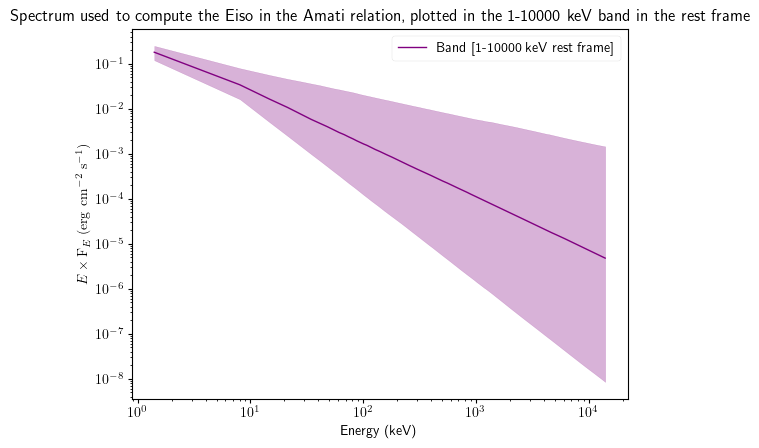

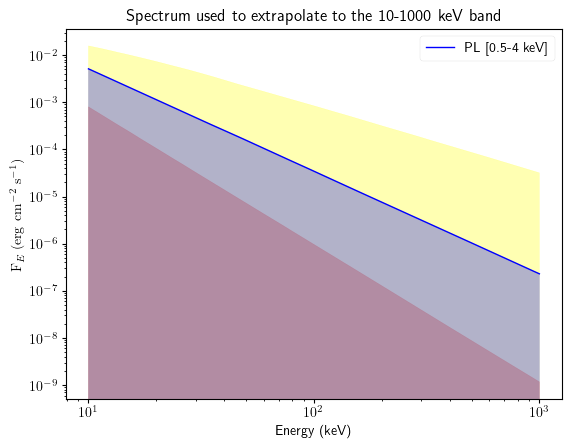

In [21]:
#Plotting the spectra in X-rays:
#Calculating the spectra for the different models:
#PL:
#Defining the energy range in keV:
EkMax=1000
EkMin=10
E_plotPL=np.linspace(EkMin,EkMax,len(Kint)) #EP-WXT observation band
SpectraPL=np.zeros((len(Kint), len(E_plotPL)))
for i in range(len(E_plotPL)):
    #SpectraPL[:, i]=E_plotPL[i]*Kint*(E_plotPL[i]**(alphaint+1))
    SpectraPL[:, i]=Kint*(E_plotPL[i]**(alphaint+1))
SpectraPLMean=np.percentile(SpectraPL, 50, axis=0)
SpectraPLPlus=np.percentile(SpectraPL, 84, axis=0)-SpectraPLMean
SpectraPLMinus=SpectraPLMean-np.percentile(SpectraPL, 16, axis=0)

#BPL:
KintBPL=FextSamplesDist['K_samples']
alphaintBPL=-1 #alpha is fixed
betaintBPL=FextSamplesDist['Beta_samples']
E_plotBPL=np.linspace(EkMin,EkMax,len(KintBPL)) #EP-WXT observation band
SpectraBPL=np.zeros((len(KintBPL), len(E_plotBPL)))
for i in range(len(E_plotBPL)):
    if E_plotBPL[i] <= Epeak:
        #SpectraBPL[:, i]=E_plotBPL[i]*KintBPL*(E_plotBPL[i]**(alpha+1))
        SpectraBPL[:, i]=KintBPL*(E_plotBPL[i]**(alphaintBPL+1))
    else:
        #SpectraBPL[:, i]=E_plotBPL[i]*KintBPL*(Epeak**(alphaintBPL-betaintBPL))*(E_plotBPL[i]**(betaintBPL+1))
        SpectraBPL[:, i]=KintBPL*(Epeak**(alphaintBPL-betaintBPL))*(E_plotBPL[i]**(betaintBPL+1))
SpectraBPLMean=np.percentile(SpectraBPL, 50, axis=0)
SpectraBPLPlus=np.percentile(SpectraBPL, 84, axis=0)-SpectraBPLMean
SpectraBPLMinus=SpectraBPLMean-np.percentile(SpectraBPL, 16, axis=0)

#Band:
KintBand=FextSamplesDistBand['K_samples']
betaintBand=FextSamplesDistBand['Beta_samples']
EbreakBand=FextSamplesDistBand['Ebreak_samples']
E_plotBand=np.linspace(EkMin,EkMax,len(KintBand)) #EP-WXT observation band
SpectraBand=np.zeros((len(KintBand), len(E_plotBand)))
for i in range(len(KintBand)):
    # Row-specific mask
    mask = E_plotBand < EbreakBand[i]
    # Low-energy branch
    #SpectraBand[i, mask] = ( E_plotBand[mask]* KintBand[i]* np.exp(-E_plotBand[mask] / Epeak))
    SpectraBand[i, mask] = (KintBand[i]* np.exp(-E_plotBand[mask] / Epeak))
    # High-energy branch
    SpectraBand[i, ~mask] = (KintBand[i]* np.exp(betaintBand[i] + 1.0)* (EbreakBand[i] ** (-1.0 - betaintBand[i]))* (E_plotBand[~mask] ** (betaintBand[i] + 1.0)))
    #SpectraBand[i, ~mask] = (E_plotBand[~mask]* KintBand[i]* np.exp(betaintBand[i] + 1.0)* (EbreakBand[i] ** (-1.0 - betaintBand[i]))* (E_plotBand[~mask] ** (betaintBand[i] + 1.0)))

SpectraBandMean=np.percentile(SpectraBand, 50, axis=0)
SpectraBandPlus=np.percentile(SpectraBand, 84, axis=0)-SpectraBandMean
SpectraBandMinus=SpectraBandMean-np.percentile(SpectraBand, 16, axis=0)


#Used for the computation of Eiso in Amati relation:

KBandAma=FextSamplesBandRest['K_samples']
betaindBandAma=FextSamplesBandRest['Beta_samples']
EbreakBandAma=FextSamplesBandRest['Ebreak_samples']
E_plotBandAma=np.linspace(1*(1+z),10000*(1+z),len(KBandAma)) #1-10000 keV band in the rest frame
SpectraBandAma=np.zeros((len(KBandAma), len(E_plotBandAma)))
for i in range(len(KBandAma)):
    # Row-specific mask
    mask = E_plotBandAma < EbreakBandAma[i]
    # Low-energy branch
    SpectraBandAma[i, mask] = ( E_plotBandAma[mask]* KBandAma[i]* np.exp(-E_plotBandAma[mask] / Epeak))
    # High-energy branch
    SpectraBandAma[i, ~mask] = (E_plotBandAma[~mask]* KBandAma[i]* np.exp(betaindBandAma[i] + 1.0)* (EbreakBandAma[i] ** (-1.0 - betaindBandAma[i]))* (E_plotBandAma[~mask] ** (betaindBandAma[i] + 1.0)))

SpectraBandAmaMean=np.percentile(SpectraBandAma, 50, axis=0)
SpectraBandAmaPlus=np.percentile(SpectraBandAma, 84, axis=0)-SpectraBandAmaMean
SpectraBandAmaMinus=SpectraBandAmaMean-np.percentile(SpectraBandAma, 16, axis=0)

plt.figure()
plt.plot(E_plotBandAma, SpectraBandAmaMean, label='Band [1-10000 keV rest frame]', color='purple')
plt.fill_between(E_plotBandAma, SpectraBandAmaMean-SpectraBandAmaMinus, SpectraBandAmaMean+SpectraBandAmaPlus, color='purple', alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy (keV)')
plt.ylabel(r'$E \times \mathrm{F}_E\;(\mathrm{erg\ cm^{-2}\ s^{-1}})$')
plt.title('Spectrum used to compute the Eiso in the Amati relation, plotted in the 1-10000 keV band in the rest frame')
plt.legend()
plt.show()

#Now, plotting the spectra:
plt.figure()
#plt.vlines(Epeak, ymin=0, ymax=2.5, linestyle='--' ,color='red', label=r'$E_{\mathrm{peak}}$')
plt.plot(E_plotPL, SpectraPLMean, label='PL [0.5-4 keV]', color='blue')
plt.fill_between(E_plotPL, SpectraPLMean-SpectraPLMinus, color='red', alpha=0.3)
plt.fill_between(E_plotPL, SpectraPLPlus-SpectraPLMean, color='yellow', alpha=0.3)
plt.fill_between(E_plotPL, SpectraPLMean, color='blue', alpha=0.3)
#plt.fill_between(E_plotPL, SpectraPLMean-SpectraPLMinus, SpectraPLMean+SpectraPLPlus, color='blue', alpha=0.3)
# plt.fill_between(E_plotPL, SpectraPLMean-SpectraPLMinus, SpectraPLMean+SpectraPLPlus, color='blue', alpha=0.3)
# plt.plot(E_plotBPL, SpectraBPLMean, label='BPL [0.5-4 keV]', color='orange')
# plt.fill_between(E_plotBPL, SpectraBPLMean-SpectraBPLMinus, SpectraBPLMean+SpectraBPLPlus, color='orange', alpha=0.3)
# plt.plot(E_plotBand, SpectraBandMean, label='Band [0.5-4 keV]', color='green')
# plt.fill_between(E_plotBand, SpectraBandMean-SpectraBandMinus, SpectraBandMean+SpectraBandPlus, color='green', alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy (keV)')
plt.ylabel(r'$\mathrm{F}_E \;(\mathrm{erg\ cm^{-2}\ s^{-1}})$')
plt.title('Spectrum used to extrapolate to the 10-1000 keV band')
plt.legend()
plt.show()

### Cheking why the errors in the integrated flux are so big (the integral is correct):

Fv: [9.94726691e-10 1.48649036e-09 1.69042460e-09 2.16575588e-09
 2.69705683e-09 2.86932189e-09 3.34071936e-09]
alp: [-5.8503496  -5.03523196 -4.48334009 -3.17539229 -1.9836896  -1.44720554
 -0.92368905]
Finteg: [2.44469227e-14 2.34952074e-13 1.24108181e-12 6.65109951e-12
 6.94815474e-11 7.98069691e-10 4.84425312e-09 5.89649142e-08
 8.93830864e-07]
[1.12723954e-04 5.91012472e-04 3.15789824e-03 3.22309535e-02
 3.57837152e-01 2.37436351e+00 2.85471122e+01]


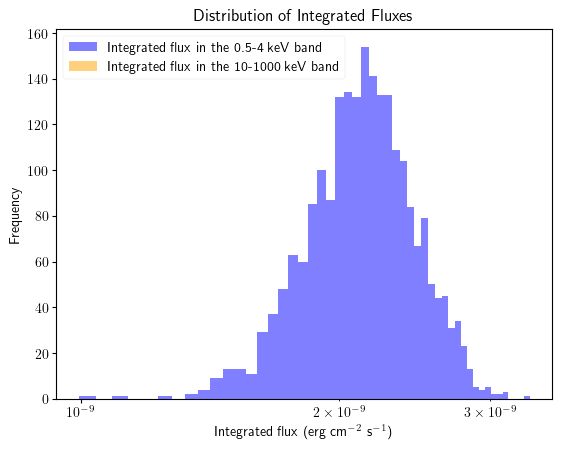

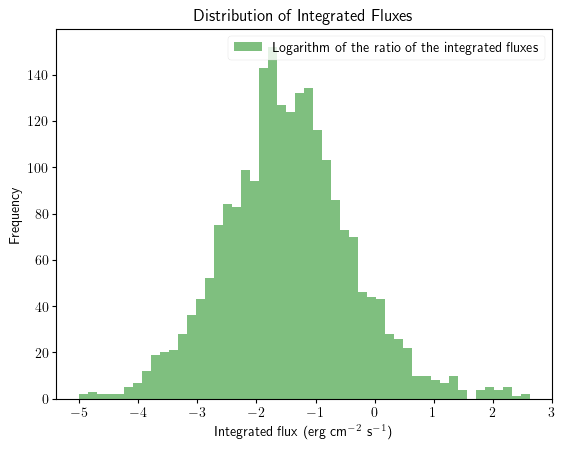

In [22]:
# In the power law model:
Finit=propagation_result['F_samples']
Fext=propagation_result['Fint_Extended']
print("Fv:", np.percentile(Finit,[0,1,5,50,95,99,100]))
print("alp:", np.percentile(alphaint,[0,1,5,50,95,99,100]))
print("Finteg:", np.percentile(Fext,[0,1,5,16,50,84,95,99,100]))
ratio = Fext / Finit
print(np.percentile(ratio,[1,5,16,50,84,95,99]))

plt.figure()
plt.hist(Finit, bins=50, alpha=0.5, label='Integrated flux in the 0.5-4 keV band', color='blue')
plt.hist(np.log10(Fext), bins=50, alpha=0.5, label='Integrated flux in the 10-1000 keV band', color='orange')
plt.xscale('log')
plt.xlabel(r'Integrated flux (erg cm$^{-2}$ s$^{-1}$)')
plt.ylabel('Frequency')
plt.title('Distribution of Integrated Fluxes')
plt.legend()
plt.show()
plt.figure()
plt.hist(np.log10(Fext/Finit), bins=50, alpha=0.5, label='Logarithm of the ratio of the integrated fluxes', color='green')
plt.xlabel(r'Integrated flux (erg cm$^{-2}$ s$^{-1}$)')
plt.ylabel('Frequency')
plt.title('Distribution of Integrated Fluxes')
plt.legend()
plt.show()

## Now, correcting $E_{peak}$ in the rest frame to find the representation for EP240414a on-axis corrected in the Amati relation:

In [23]:
#E_peak on axis is:
EpeakOff=1.3 #keV, from the spectral fitting of the prompt emission (off-axis)
#But let's assume that it is just a point since we do not have its distribution.
#From Granot et al. (2017), assuming a uniform (top-hat) jet with sharp edges:
def EpeakOnFromOffTophat(EpeakOff, Gamma, thetav, thetajet):
        return EpeakOff * (1 + (Gamma*(thetav-thetajet))**2)
    
#From Salafia et al. 2022 approximation for LGRBs with Gaussian jets:
def EpeakOnFromOffSalafia(EpeakOff, Gamma, thetav, thetajet):
        return EpeakOff * (Gamma/GammaGauss(Gamma, thetav, thetajet))



EpeakOnSalfApproxDist=EpeakOnFromOffSalafia(EpeakOff*(1+z), posterior_final_model['g0'].values, posterior_final_model['thv'].values, posterior_final_model['thc'].values)
EpeakOnSalfApproxMean=pct(EpeakOnSalfApproxDist, 50)
EpeakOnSalfApproxMinus=pct(EpeakOnSalfApproxDist, 50)-pct(EpeakOnSalfApproxDist, 16)
EpeakOnSalfApproxPlus=pct(EpeakOnSalfApproxDist, 84)-pct(EpeakOnSalfApproxDist, 50)

EpeakOnDist=EpeakOnFromOffTophat(EpeakOff*(1+z), posterior_final_model['g0'].values, posterior_final_model['thv'].values, posterior_final_model['thc'].values)
EpeakOnMean=pct(EpeakOnDist, 50)
EpeakOnMeanMinus=pct(EpeakOnDist, 50)-pct(EpeakOnDist, 16)
EpeakOnMeanPlus=pct(EpeakOnDist, 84)-pct(EpeakOnDist, 50)

display(Math(rf"\text{{Now, for the peak energy, the upper bound reported by Sun et al. (2025) is:}} " ),
        Math(rf"E_{{\text{{peak, off}}}} (1+z) < {EpeakOff*(1+z):.2f} \text{{ keV}}" )
)
display(Math(rf"\text{{So, assuming a uniform (top-hat) jet with sharp edges, from  Granot et al. (2017) (assuming Epeak=1.3keV):}} " ),
        Math(rf"E_{{\text{{peak, on}}}} (1+z) = {EpeakOnMean:.2f}^{{+{EpeakOnMeanPlus:.2f}}}_{{-{EpeakOnMeanMinus:.2f}}} \text{{ keV}}" )
)
display(Math(rf"\text{{Assuming a gaussian jet in which the emission is dominated by the emission on the line of sight, from  Salafia et al. (2022) (assuming Epeak=1.3keV):}} " ),
        Math(rf"E_{{\text{{peak, on}}}} (1+z) < {EpeakOnSalfApproxMean:.2f} \text{{ keV}}" )
)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

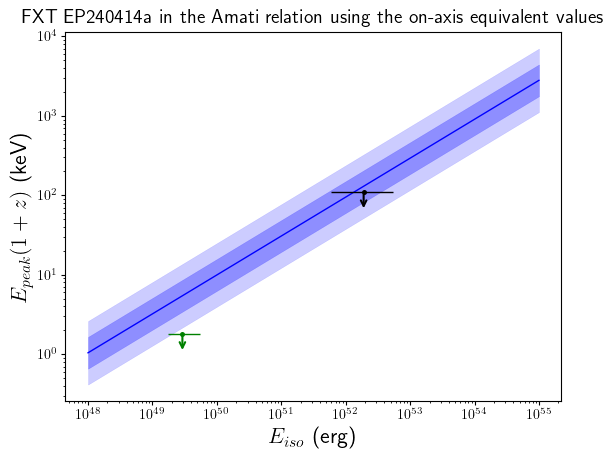

In [24]:
# The Amati relation is an empirical correlation between the isotropic equivalent 
# energy emitted in the prompt emission (Eiso) and the peak energy of the prompt emission 
# spectrum (Epeak). It is usually expressed as a power-law relation: Epeak = K * (Eiso)^m,
# where K and m are constants determined from observational data.
# From Amati et al. (2006):
EisoPlotSamples=np.logspace(48, 55, Nsamples)/1e52
K=95 #From Amati et al. (2006)
m=0.49 #From Amati et al. (2006)
EpeakPlot=K * (EisoPlotSamples**m)


#Then, plotting the results:
fig5, ax5 = plt.subplots()
ax5.plot(EisoPlotSamples*1e52, EpeakPlot, color='blue', label='Amati relation (Amati et al. 2006)')
ax5.fill_between(EisoPlotSamples*1e52, EpeakPlot*10**0.4, EpeakPlot/(10**0.4), color='blue', alpha=0.2, label=r'2$\sigma$ confidence interval of the Amati relation')
ax5.fill_between(EisoPlotSamples*1e52, EpeakPlot*10**0.2, EpeakPlot/(10**0.2), color='blue', alpha=0.3, label=r'1$\sigma$ confidence interval of the Amati relation')
# ax5.errorbar(EisoOnMean, EpeakOnMean*(1+z), xerr=np.vstack([EisoOnMinus, EisoOnPlus]), color='red', fmt='o', label=rf'[0.5,4] keV on-axis (Granot et al. 2017)')
# ax5.annotate('', xy=(EisoOnMean,  EpeakOnMean*(1+z) / 1.75), xytext=(EisoOnMean, EpeakOnMean*(1+z)), arrowprops=dict(arrowstyle='->', color='red'))
# ax5.errorbar(EisoOnMean, EpeakOnSalfApproxMean*(1+z), xerr=np.vstack([EisoOnMinus, EisoOnPlus]), color='black', fmt='o', label=rf'[0.5,4] keV on-axis (Salafia et al. 2022)')
# ax5.annotate('', xy=(EisoOnMean,  EpeakOnSalfApproxMean*(1+z) / 1.75), xytext=(EisoOnMean, EpeakOnSalfApproxMean*(1+z)), arrowprops=dict(arrowstyle='->', color='black'))
# ax5.errorbar(Eiso.value, EpeakOff*(1+z), xerr=np.vstack([Eiso_e.value, Eiso_E.value]), color='cyan', fmt='o', label=rf'[0.5,4] keV off-axis (Sun et al. 2025)')
# ax5.annotate('', xy=(Eiso.value,  EpeakOff*(1+z) / 1.75), xytext=(Eiso.value, EpeakOff*(1+z)), arrowprops=dict(arrowstyle='->', color='cyan'))


ax5.errorbar(EisoExtMeanBandRest, EpeakOff*(1+z), xerr=np.vstack([EisoExtMinusBandRest,EisoExtPlusBandRest]), color='green', fmt='o', label=rf'$[1,10^4]$ keV rest frame off-axis (Sun et al. 2025)')
ax5.annotate('', xy=(EisoExtMeanBandRest,  EpeakOff*(1+z) / 1.75), xytext=(EisoExtMeanBandRest, EpeakOff*(1+z)), arrowprops=dict(arrowstyle='->',lw=1.5, color='green'))
ax5.errorbar(EisoOnAmatiMean, EpeakOnSalfApproxMean, xerr=np.vstack([EisoOnAmatiMinus,EisoOnAmatiPlus]), color='black', fmt='o', label=rf'$[1,10^4]$ keV rest frame on-axis (Salafia et al. 2022)')
ax5.annotate('', xy=(EisoOnAmatiMean,  EpeakOnSalfApproxMean / 1.75), xytext=(EisoOnAmatiMean, EpeakOnSalfApproxMean), arrowprops=dict(arrowstyle='->',lw=1.5, color='black'))
# ax5.errorbar(EisoOnAmatiMean, EpeakOnMean*(1+z), xerr=np.vstack([EisoOnAmatiMinus,EisoOnAmatiPlus]), color='yellow', fmt='o', label=rf'$[1,10^4]$ keV rest frame on-axis (Granot et al. 2017)')
# ax5.annotate('', xy=(EisoOnAmatiMean,  EpeakOnMean*(1+z) / 1.75), xytext=(EisoOnAmatiMean, EpeakOnMean*(1+z)), arrowprops=dict(arrowstyle='->', color='yellow'))


ax5.set_xscale('log')
ax5.set_yscale('log')
ax5.set_xlabel(r'$E_{iso}$ (erg)', fontsize=16)
ax5.set_ylabel(r'$E_{peak} (1+z)$ (keV)', fontsize=16)
ax5.set_title('FXT EP240414a in the Amati relation using the on-axis equivalent values', fontsize=14)
#ax5.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()
plt.close(fig5)

Finally, the radiative efficiency defined in gamma rays for the Fermi GBM observer frame band is:

In [25]:
#Using the Band function shape of the spectrum to approximate it:
RadEffGammaDist=RadEff(EisoOnAmati,sample_split_normal(np.percentile(Ekin, 50), np.percentile(Ekin, 50)-np.percentile(Ekin, 16), np.percentile(Ekin, 84)-np.percentile(Ekin, 50),len(EisoOnAmati)))*100 #In percentage
RadEffGammaMean=np.percentile(RadEffGammaDist, 50)
RadEffGammaPlus=np.percentile(RadEffGammaDist, 84) - np.percentile(RadEffGammaDist, 50)
RadEffGammaMinus=np.percentile(RadEffGammaDist, 50) - np.percentile(RadEffGammaDist, 16)

#For comparison, we can also compute the radiative efficiency off-axis in Gamma-rays using the distribution of E_0
#over the structure of the jet:
Ekinoff=EkinGauss(Ekin, posterior_final_model['thv'].values, posterior_final_model['thc'].values)
print(np.percentile(Ekinoff, 50), np.percentile(Ekinoff, 16), np.percentile(Ekinoff, 84))

#So, for the radiative efficiency in the off-axis case for the pseudobolometric band:
RadEffOffGammaDist=RadEff(EisoExtMeanBandRest, Ekinoff)*100 #In percentage
RadEffOffGammaMean=np.percentile(RadEffOffGammaDist, 50)
RadEffOffGammaPlus=np.percentile(RadEffOffGammaDist, 84) - np.percentile(RadEffOffGammaDist, 50)
RadEffOffGammaMinus=np.percentile(RadEffOffGammaDist, 50) - np.percentile(RadEffOffGammaDist, 16)


print(np.percentile(EisoExtMeanBandRest, 50), np.percentile(EisoExtMeanBandRest, 16), np.percentile(EisoExtMeanBandRest, 84))

display(Math(rf"\text{{The radiative efficiency in gamma rays computed using the on-axis Eiso extrapolated to the 1-10000 keV rest frame band using the Band function is:}}" ),
        Math(rf"\eta_{{\gamma, [1-10000] keV}} = {RadEffGammaMean:.2f}^{{+{RadEffGammaPlus:.2f}}}_{{-{RadEffGammaMinus:.2f}}} \%" )
    )

display(Math(rf"\text{{The radiative efficiency in gamma rays computed using the viewing angle kinetic Energy from the afterglow modeling and the off-axis Eiso extrapolated to the 1-10000 keV rest frame band using the Band function is:}}" ),
        Math(rf"\eta_{{\gamma, off}} = {RadEffOffGammaMean:.2f}^{{+{RadEffOffGammaPlus:.2f}}}_{{-{RadEffOffGammaMinus:.2f}}} \%" )
    )

4.7673638531405544e+33 3.6539059454370853e+25 1.272264104878588e+40
2.917292942493201e+49 2.917292942493201e+49 2.917292942493201e+49


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Lastly, also studying the true energetics of the system, this is, beaming correcting the energy:

In [26]:
# Firstly, calculating the beaming factor:
# We are going to start calculating the beaming factor for a gaussian jet.
# Notice that for a top-hat jet it would be just f=1-cos(theta_jet). Then:

#Integration variables and terms:
thetainteg=np.linspace(0, np.pi/2, 400)
phiinteg=np.linspace(0, 2*np.pi, 400)

Thetagrid, Phigrid = np.meshgrid(thetainteg, phiinteg, indexing='ij')

sinint = np.sin(Thetagrid)

#Preparing the setup for the integration over the jet surface:
theta_c_calc = posterior_final_model['thc'].values[:, None, None]  # (Np,1,1)
Ekin_calc = 10**posterior_final_model['loge0'].values[:, None, None]  # (Np,1,1)

ThetagridCalc = Thetagrid[None, :, :]   # (1,Nint,Nint)
PhigridCalc = Phigrid[None, :, :]       # (1,Nint,Nint)
sinintCalc = sinint[None, :, :]         # (1,Nint,Nint)

#Defining the integrand with the Gaussian jet structure:
integrand=EkinGauss(Ekin_calc, ThetagridCalc, theta_c_calc)*sinintCalc / (4*np.pi)

# integrating over theta axis
int_theta = sc.integrate.simps(integrand, thetainteg, axis=1)   # (Np,Nint)

# integrating over phi axis
Ektrue = sc.integrate.simps(int_theta, phiinteg, axis=1)    # (Np,)
    

# The beaming factor is then:
fb=Ektrue/Ekin #Dimensionless

fbMean=np.percentile(fb, 50)
fbPlus=np.percentile(fb, 84) - np.percentile(fb, 50)
fbMinus=np.percentile(fb, 50) - np.percentile(fb, 16)
fbMan, fbExp = sci_notation(fbMean)

#Then, the beaming corrected energy in the 1-10000 keV rest frame band is:
EgammaTrue=sample_split_normal(EisoOnAmatiMean, EisoOnAmatiMinus, EisoOnAmatiPlus, len(fb))*fb
EgammaTrueMean=np.percentile(EgammaTrue, 50)
EgammaTruePlus=np.percentile(EgammaTrue, 84) - np.percentile(EgammaTrue, 50)
EgammaTrueMinus=np.percentile(EgammaTrue, 50) - np.percentile(EgammaTrue, 16)
EgammaTrueMan, EgammaTrueExp = sci_notation(EgammaTrueMean)

#Now, the beaming corrected kinetic energy is:
EktrueMean=np.percentile(Ektrue, 50)
EktruePlus=np.percentile(Ektrue, 84) - np.percentile(Ektrue, 50)
EktrueMinus=np.percentile(Ektrue, 50) - np.percentile(Ektrue, 16)
EktrueMan, EktrueExp = sci_notation(EktrueMean)


display(Math(rf"\text{{The beaming corrected energy in the 1-10000 keV rest frame band (on-axis) is:}}" ),
        Math(rf"E_{{\gamma, \text{{true}}}} = {EgammaTrueMan:.2f}^{{+{EgammaTruePlus/(10**EgammaTrueExp):.2f}}}_{{-{EgammaTrueMinus/(10**EgammaTrueExp):.2f}}} \, \times 10^{{{EgammaTrueExp}}} \, \mathrm{{erg}}" )
    )
display(Math(rf"\text{{The beaming corrected kinetic energy (on-axis) is:}}" ),
        Math(rf"E_{{k, \text{{true}}}} = {EktrueMan:.2f}^{{+{EktruePlus/(10**EktrueExp):.2f}}}_{{-{EktrueMinus/(10**EktrueExp):.2f}}} \, \times 10^{{{EktrueExp}}} \, \mathrm{{erg}}" )
    )

display(Math(rf"\text{{The beaming factor is:}}" ),
        Math(rf"f_b = {fbMan:.2f}^{{+{fbPlus/(10**fbExp):.2f}}}_{{-{fbMinus/(10**fbExp):.2f}}} \, \times 10^{{{fbExp}}} \, \mathrm{{erg}}" )
    )

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Lastly, with the off-axis integrated flux in the Fermi-GBM observation band, we can compute the expected on-axis integrated flux in this band as:

In [27]:
#Number of points:
Ng=250 #Gamma0 points
Np=200 #Viewing angle points
Nint=200 # Integration points

#Gamma values at the center of the jet:
GammaVal=np.logspace(1,3,Ng)
#Viewing angle factor values in degrees!:
VVAL=np.linspace(0,np.rad2deg(q_final.loc['thv', 'P50'])*2,Np) #degrees
VVALM, GammaVM=np.meshgrid(VVAL, GammaVal) #shapes of this (Np, Ng)

#Defining the variables over which we are going to integrate:
phiint=np.linspace(0,2*np.pi,Nint)

#Defining the variables for our integrated Eiso off and on axis:
Foff=np.zeros((Ng,Np)) #First index gammas and second index Pvals.
Fon=np.zeros((Ng)) #This only depends on gamma, thetav=0 so Pvals.
#Now, for the theta integration parameter:
thetaInt=np.linspace(0,np.deg2rad(thetaedge),Nint)
#Creating the grid over which we are going to integrate:
Thetagrid, Phigrid = np.meshgrid(thetaInt, phiint, indexing='ij') #shapes of this (Nint, Nint)
#Computing the sin of the integral first:
sinint=np.sin(Thetagrid) #Shape (Nint, Nint)
#Now, let's make first the loop of the integration for gamma:
for GammaInd, Gamma in enumerate(GammaVal):
    #Now, we want to compute the Doppler factor for all VVAL at once
    #But VVAL's shape is (Np), and since we want to integrate afterwards over 
    #Theta and phi, we need to work with variables with three indeces, i.e.
    # shape (something,something,something), to do so:
    VarrCalc=VVAL[:, None, None] #Shape of this now: (Np,1,1)
    #Similarly, for the integration variables:
    ThetagridCalc=Thetagrid[None,:,:] #Shape of this now: (1,Nint,Nint)
    PhigridCalc=Phigrid[None,:,:] #Shape of this now: (1,Nint,Nint)
    #Now, calculating all the Doppler factors at once for the off-axis case and for each Gamma (that depend also on the angles):
    Doff=Doppler(GammaGauss(Gamma,ThetagridCalc,np.deg2rad(thetajet)),np.deg2rad(VarrCalc),ThetagridCalc,PhigridCalc) #shape of this: (Np,Nint,Nint)
    #For the new term from the gaussian distributions:
    NToff=Gamma - 1 + np.exp(0.5*((Thetagrid/np.deg2rad(thetajet))**2)) #Shape of this now: (1,Nint,Nint)

    #Now, for the integrand of the off-axis integral:
    integrandoff=sinint[None,:,:]*(Doff**4)*(NToff[None,:,:]**-1) #The trick in the sine to match the shapes. Now: (Np, Nint,Nint)
        
    #Integrating, first over theta and then over phi:
    Fofftheta=sc.integrate.simps(integrandoff,thetaInt, axis=1) #axis=1 to integrate over the second array, shape after this: (Np, Nint)
    FoffVval=sc.integrate.simps(Fofftheta,phiint, axis=1) #Shape after this: (Np), but this is only for the first gamma, so:
    Foff[GammaInd,:]=FoffVval

    #For the new term from the gaussian distributions:
    NTon=Gamma - 1 + np.exp(0.5*((Thetagrid/np.deg2rad(thetajet))**2)) #shape=(Nint,Nint)
    #Now, the same for the on axis case (simpler since Vval=0). We don't need the trick of the shapes for this:
    Don=Doppler(GammaGauss(Gamma,Thetagrid,np.deg2rad(thetajet)),0,Thetagrid,Phigrid) #shape=(Nint,Nint)
    #For the integrand:
    integrandon=sinint*(Don**4)*(NTon**-1) #Shape=(Nint,Nint)

    #So, integrating:
    Fontheta=sc.integrate.simps(integrandon,thetaInt,axis=0)
    FonScalar=sc.integrate.simps(Fontheta, phiint, axis=0) #This return a scalar since Vvals=0
    Fon[GammaInd]=FonScalar #Shape after the whole loop =(Ng)

    #After this loop we have Foff with shape (Ng, Np) for all the values of gamma and v angle and 
    #Fon with shape (Ng). Then, calculating their ratio now:
    Fongrid=Fon[:, None] #Now shape (Ng,1)

    #Calculating the ratio:
    FisoRat=np.log10(Foff/Fongrid)
    FisoRat_masked = np.ma.masked_invalid(FisoRat)
    FisoRat[FisoRat > 0] = 0 #Since the ratio cannot be greater than 1, we set all the values greater than 0 to 0 
                            #(since we are in log10 space). This is caused by numerical instabilities when 
                            #theta edje is very large compared to thetajet.
    #Levels of the contour I will mark:
    levels_to_mark = [-0.3,-0.5,-1,-2,-3,-4,-5]
    levels_to_mark=sorted(levels_to_mark)

# Now, in order to know the valeu of the ratio for a particular combination of gammas and viewing angles, 
# that is the think we want to achieve in order to know what would be the Fiso measured from an on-axis point
# of view for a particular combination, we can interpolate using scipy as:
FisoRatInterp=sc.interpolate.RegularGridInterpolator((GammaVal, VVAL), FisoRat, bounds_error=True, fill_value=None) #np.log10 since I used logspace (for a smoother interpolation)

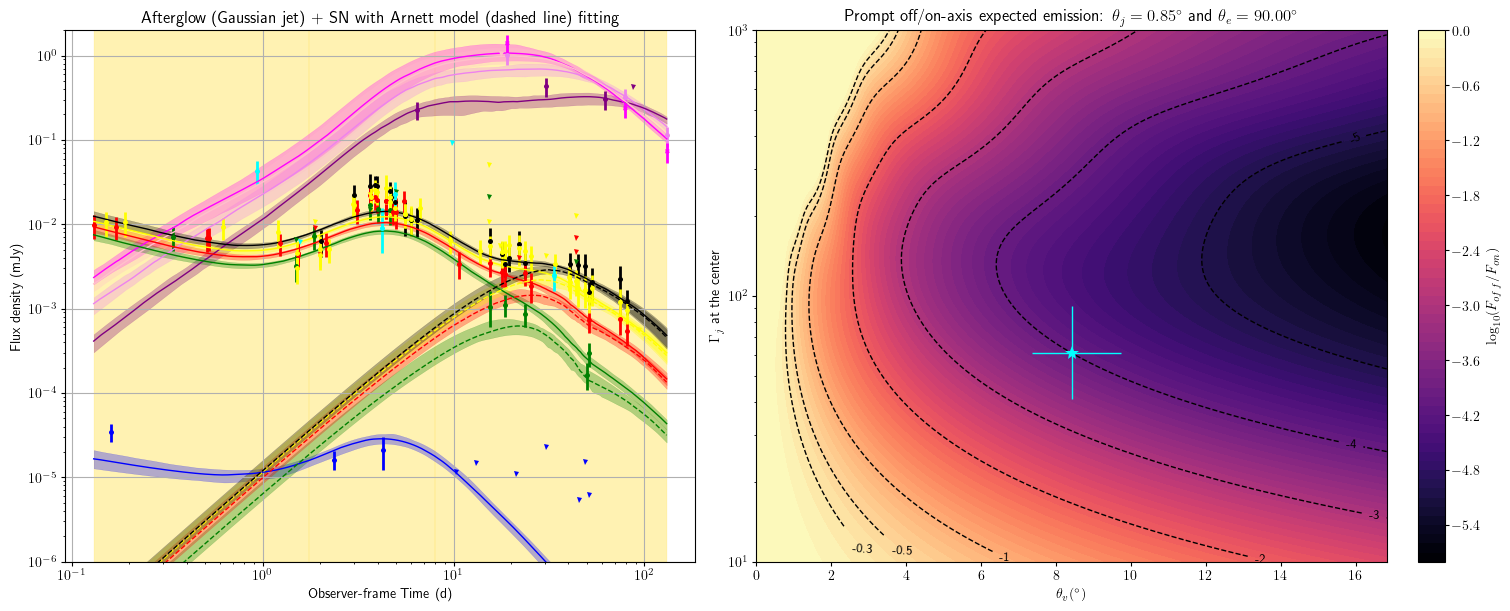

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [28]:
fig3, (ax1,ax2) = plt.subplots(1, 2, figsize=(15, 6), layout="constrained")
#Data points:
#g band
ax1.errorbar(Optical['Since-Trigger-Observed(s)'].value[gind]*stod, 1e-3*Optical['Flux-Density(micro-Jankys)'].value[gind], yerr=np.vstack([np.hypot(1e-3*Optical['Flux-Density_e(micro-Jankys)'].value[gind],  f_relOPT*1e-3*Optical['Flux-Density(micro-Jankys)'].value[gind]), np.hypot(1e-3*Optical['Flux-Density_E(micro-Jankys)'].value[gind], f_relOPT*1e-3*Optical['Flux-Density(micro-Jankys)'].value[gind])]), fmt='o', capsize=5, elinewidth=2 ,label= 'g Data', color='green')
ax1.errorbar(Optical['Since-Trigger-Observed(s)'].value[gUBind]*stod, 1e-3*Optical['Flux-Density(micro-Jankys)'].value[gUBind], fmt='v', capsize=5, elinewidth=2, color='green')
#z band
ax1.errorbar(Optical['Since-Trigger-Observed(s)'].value[zind]*stod, 1e-3*Optical['Flux-Density(micro-Jankys)'].value[zind], yerr=np.vstack([np.hypot(1e-3*Optical['Flux-Density_e(micro-Jankys)'].value[zind],  f_relOPT*1e-3*Optical['Flux-Density(micro-Jankys)'].value[zind]), np.hypot(1e-3*Optical['Flux-Density_E(micro-Jankys)'].value[zind], f_relOPT*1e-3*Optical['Flux-Density(micro-Jankys)'].value[zind])]), fmt='o', capsize=5, elinewidth=2 ,label= 'z Data', color='black')
#r band
ax1.errorbar(Optical['Since-Trigger-Observed(s)'].value[rind]*stod, 1e-3*Optical['Flux-Density(micro-Jankys)'].value[rind], yerr=np.vstack([np.hypot(1e-3*Optical['Flux-Density_e(micro-Jankys)'].value[rind],  f_relOPT*1e-3*Optical['Flux-Density(micro-Jankys)'].value[rind]), np.hypot(1e-3*Optical['Flux-Density_E(micro-Jankys)'].value[rind], f_relOPT*1e-3*Optical['Flux-Density(micro-Jankys)'].value[rind])]), fmt='o', capsize=5, elinewidth=2 ,label= 'r Data', color='red')
ax1.errorbar(Optical['Since-Trigger-Observed(s)'].value[rUBind]*stod, 1e-3*Optical['Flux-Density(micro-Jankys)'].value[rUBind], fmt='v', capsize=5, elinewidth=2, color='red')
#i band
ax1.errorbar(Optical['Since-Trigger-Observed(s)'].value[iind]*stod,  1e-3*Optical['Flux-Density(micro-Jankys)'].value[iind], yerr=np.vstack([np.hypot(1e-3*Optical['Flux-Density_e(micro-Jankys)'].value[iind],  f_relOPT*1e-3*Optical['Flux-Density(micro-Jankys)'].value[iind]), np.hypot(1e-3*Optical['Flux-Density_E(micro-Jankys)'].value[iind], f_relOPT*1e-3*Optical['Flux-Density(micro-Jankys)'].value[iind])]), fmt='o', capsize=5, elinewidth=2 ,label= 'i Data', color='yellow')
ax1.errorbar(Optical['Since-Trigger-Observed(s)'].value[iUBind]*stod, 1e-3*Optical['Flux-Density(micro-Jankys)'].value[iUBind], fmt='v', capsize=5, elinewidth=2, color='yellow')

#IRUV data:
ax1.errorbar(IRUV['Since-Trigger-Observed (s)'].value[IRUVDet]*stod,  1e-3*IRUV['Flux-Density(micro-Jankys)'].value[IRUVDet], yerr=np.vstack([np.hypot(1e-3*IRUV['Flux-Density_e(micro-Jankys)'].value[IRUVDet],  f_relOPT*1e-3*IRUV['Flux-Density(micro-Jankys)'].value[IRUVDet]), np.hypot(1e-3*IRUV['Flux-Density_E(micro-Jankys)'].value[IRUVDet], f_relOPT*1e-3*IRUV['Flux-Density(micro-Jankys)'].value[IRUVDet])]), fmt='o', capsize=5, elinewidth=2 ,label= 'Infrared/Ultraviolet Data', color='cyan')
ax1.errorbar(IRUV['Since-Trigger-Observed (s)'].value[~IRUVDet]*stod, 1e-3*IRUV['Flux-Density(micro-Jankys)'].value[~IRUVDet], fmt='v', capsize=5, elinewidth=2, color='cyan')

#Radio band
#3GHz
ax1.errorbar(Radio['Since-Trigger-Observed(s)'].value[GHz3Dat]*stod,1e-3*Radio['Flux-Density-(micro-Jankys)'].value[GHz3Dat], yerr=np.hypot(1e-3*Radio['Flux-Density-error-(micro-Jankys)'].value[GHz3Dat], f_relRAD*1e-3*Radio['Flux-Density-(micro-Jankys)'].value[GHz3Dat]), fmt='o', capsize=5, elinewidth=2 ,label= 'Radio [3GHz] Data', color='purple')
ax1.errorbar(Radio['Since-Trigger-Observed(s)'].value[GHz3UB]*stod, 1e-3*Radio['Flux-Density-(micro-Jankys)'].value[GHz3UB], fmt='v', capsize=5, elinewidth=2, color='purple')
#5.5GHz
ax1.errorbar(Radio['Since-Trigger-Observed(s)'].value[GHz5Dat]*stod,1e-3*Radio['Flux-Density-(micro-Jankys)'].value[GHz5Dat], yerr=np.hypot(1e-3*Radio['Flux-Density-error-(micro-Jankys)'].value[GHz5Dat], f_relRAD*1e-3*Radio['Flux-Density-(micro-Jankys)'].value[GHz5Dat]), fmt='o', capsize=5, elinewidth=2 ,label= 'Radio [5.5GHz] Data', color='violet')

#9GHz
ax1.errorbar(Radio['Since-Trigger-Observed(s)'].value[GHz9Dat]*stod,1e-3*Radio['Flux-Density-(micro-Jankys)'].value[GHz9Dat], yerr=np.hypot(1e-3*Radio['Flux-Density-error-(micro-Jankys)'].value[GHz9Dat], f_relRAD*1e-3*Radio['Flux-Density-(micro-Jankys)'].value[GHz9Dat]), fmt='X', capsize=5, elinewidth=2 ,label= 'Radio [9GHz] Data', color='magenta')

#8GHz
ax1.errorbar(Radio['Since-Trigger-Observed(s)'].value[GHz8UB]*stod,1e-3*Radio['Flux-Density-(micro-Jankys)'].value[GHz8UB], fmt='v', capsize=5, elinewidth=2 ,label= 'Radio [8GHz] Data', color='pink')

#Xrays
ax1.errorbar(Xray['Since-Trigger-Observed(s)'].value[3:][XRAYDat]*stod,  1e-3*Xray['Flux-Density(micro-Jankys)'].value[3:][XRAYDat], yerr=np.vstack([1e-3*Xray['Flux-Density_e(micro-Jankys)'].value[3:][XRAYDat],1e-3*Xray['Flux-Density_E(micro-Jankys)'].value[3:][XRAYDat]]), fmt='o', capsize=5, elinewidth=2 ,label= 'Xray [1keV] Data', color='blue')
ax1.errorbar(Xray['Since-Trigger-Observed(s)'].value[3:][~XRAYDat]*stod, 1e-3*Xray['Flux-Density(micro-Jankys)'].value[3:][~XRAYDat], fmt='v', capsize=5, elinewidth=2, color='blue')

#Different regions:
ax1.axvspan(TimesObservedSorted[0], 1.75, color="gold", alpha=0.3)
ax1.axvspan(1.75, 8, color="gold", alpha=0.3)
ax1.axvspan(8, TimesObservedSorted[-1], color="gold", alpha=0.3)


#Fitting curves with 1σ band:

#Radio bands:
ax1.plot(t_grid, p505R, color="violet", label=rf"model Radio [5.5GHz] ($1\sigma$)")
ax1.fill_between(t_grid, p165R, p845R, color="violet", alpha=0.3)

ax1.plot(t_grid, p503R, color="purple", label=rf"model Radio [3GHz] ($1\sigma$)")
ax1.fill_between(t_grid, p163R, p843R, color="purple", alpha=0.3)

ax1.plot(t_grid, p509R, color="magenta", label=rf"model Radio [9GHz] ($1\sigma$)")
ax1.fill_between(t_grid, p169R, p849R, color="magenta", alpha=0.3)

ax1.plot(t_grid, p508R, color="pink", label=rf"model Radio [8GHz] ($1\sigma$)")
ax1.fill_between(t_grid, p168R, p848R, color="pink", alpha=0.3)

ax1.plot(t_grid, p503RSN, color="purple", linestyle='--')
ax1.fill_between(t_grid, p163RSN, p843RSN, color="purple", alpha=0.3)

ax1.plot(t_grid, p505RSN, color="violet", linestyle='--')
ax1.fill_between(t_grid, p165RSN, p845RSN, color="violet", alpha=0.3)

ax1.plot(t_grid, p509RSN, color="magenta", linestyle='--')
ax1.fill_between(t_grid,p169RSN,p849RSN,color='magenta',alpha=0.3)

ax1.plot(t_grid,p508RSN,color='pink',linestyle='--')
ax1.fill_between(t_grid,p168RSN,p848RSN,color='pink',alpha=0.3)

#X-ray band:
ax1.plot(t_grid, p50XSN ,color='blue', linestyle='--')
ax1.fill_between(t_grid,p16XSN,p84XSN,color='blue',alpha=0.3)

ax1.plot(t_grid,p50X,color='blue',label=rf"model X-ray [1keV] ($1\sigma$)")
ax1.fill_between(t_grid,p16X,p84X,color='blue',alpha=0.3)

#Optical bands:
ax1.plot(t_grid,p50gSN,color='green', linestyle='--')
ax1.fill_between(t_grid,p16gSN,p84gSN,color='green',alpha=0.3)

ax1.plot(t_grid,p50g,color='green',label=rf"model g ($1\sigma$)")
ax1.fill_between(t_grid,p16g,p84g,color='green',alpha=0.3)

ax1.plot(t_grid, p50r, color="red", label=rf"model r ($1\sigma$)")
ax1.fill_between(t_grid, p16r, p84r, color="red", alpha=0.3)

ax1.plot(t_grid, p50rSN, color="red", linestyle='--')
ax1.fill_between(t_grid, p16rSN, p84rSN, color="red", alpha=0.3)

ax1.plot(t_grid, p50i, color="yellow", label=rf"model i ($1\sigma$)")
ax1.fill_between(t_grid, p16i, p84i, color="yellow", alpha=0.3)

ax1.plot(t_grid, p50iSN, color="yellow", linestyle='--')
ax1.fill_between(t_grid, p16iSN, p84iSN, color="yellow", alpha=0.3)

ax1.plot(t_grid, p50z, color="black", label=rf"model z ($1\sigma$)")
ax1.fill_between(t_grid, p16z, p84z, color="black", alpha=0.3)

ax1.plot(t_grid, p50zSN, color="black", linestyle='--')
ax1.fill_between(t_grid, p16zSN, p84zSN, color="black", alpha=0.3)

# ax1.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
ax1.set_xscale('log')
ax1.set_yscale('log')
# ax.set_xlim(10, TimesObservedSorted[-1])
ax1.set_ylim(1e-6, 2)
ax1.grid()
ax1.set_ylabel('Flux density (mJy)')
ax1.set_xlabel('Observer-frame Time (d)')
# ax1.set_title(rf'Afterglow (Gaussian with VegasAfterglow) + SN (dashed line, Arnett model) fitting of the data. LogZ = {ready_final_model.log_evidence:.2f} $\pm$ {ready_final_model.log_evidence_err:.2f}')
ax1.set_title(rf'Afterglow (Gaussian jet) + SN with Arnett model (dashed line) fitting')



#Now, for the prompt plot: 
cs = ax2.contourf(VVALM, GammaVM, FisoRat, levels=60, cmap=mpl.colormaps['magma'])
# overlay a contour line at log10(ratio) = -5
# style arrays sized to the number of levels
cs_lines=ax2.contour(VVALM, GammaVM, FisoRat_masked,
                     levels=levels_to_mark,
                     colors='black', linewidths=1.0, linestyles='--')
# build labels for each level and put them on the contours
fmt = {lvl: rf'{lvl}' for lvl in levels_to_mark}
ax2.clabel(cs_lines, fmt=fmt, inline=True, fontsize=9)
ax2.errorbar(np.rad2deg(q_final.loc['thv', 'P50']), q_final.loc['g0', 'P50'], xerr=np.vstack([np.rad2deg(q_final.loc['thv', 'P50'])-np.rad2deg(q_final.loc['thv', 'P16']), np.rad2deg(q_final.loc['thv', 'P84'])-np.rad2deg(q_final.loc['thv', 'P50'])]), yerr=np.vstack([q_final.loc['g0', 'P50']-q_final.loc['g0', 'P16'], q_final.loc['g0', 'P84']-q_final.loc['g0', 'P50']]), fmt='*', c='cyan', markersize=10)
ax2.set_xlabel(r'$\theta_v (^{\circ})$')
ax2.set_ylabel(r'$\Gamma_j$ at the center')
ax2.set_title(rf'Prompt off/on-axis expected emission: $\theta_j = {thetajet:.2f}^\circ$ and $\theta _e= {thetaedge:.2f}^\circ$')
ax2.set_yscale('log')
fig3.colorbar(cs, label=r'$\log_{10}(F_{off} / F_{on})$')
ax2.set_ylim(GammaVal.min(), GammaVal.max())
ax2.set_xlim(VVAL.min(), VVAL.max())

plt.show()
plt.close(fig3)

# Now, to know the effect of this ratio in the prompt emission, we can use the contour plot to know the value of the 
# ratio of Eiso off and on axis for this particular combination of parameters. However, there is no a linear 
# relation between gamma, thetav and Eiso ratio, so we need to interpolate in the contour plot and 
# deal with the distribution of the paramters extracted from the posterior of the fitting. To do so, 
# we can use the function defined above to interpolate the contour plot and the posterior distribution already stored.

#For the computations with percentiles:
def pct(arr, p):
        return np.percentile(arr, p)

#Extracting the samples of the parameters from the posterior distribution:
ThetaVSamples=np.rad2deg(posterior_final_model['thv'].values)
GammaSamples=posterior_final_model['g0'].values


#Interpolating the contour plot for each of the samples:
CombinedSamples=np.column_stack([GammaSamples,ThetaVSamples])
#We do this because the posterior results are correlated from the Bayesian parameter inference,
#this is; F(Gamma_i, Theta_v_i) no F(Gamma_i, Theta_v_j), which breaks correlations from the 
#posterior distribution.


#So:
FisoRatSamples=FisoRatInterp(CombinedSamples)
FisoRatMean=pct(FisoRatSamples, 50)
FisoRatPlus=pct(FisoRatSamples, 84) - pct(FisoRatSamples, 50)
FisoRatMinus=pct(FisoRatSamples, 50) - pct(FisoRatSamples, 16)

#Obtained Foff from the extension to gamma rays assuming an spectrum:
FisoOffDist=sample_split_normal(FextNewBANDMean, FextNewBANDMinus, FextNewBANDPLUS, size=len(GammaSamples))
FisoOnDist=FisoOffDist/(10**FisoRatSamples)
FisoOnMean=pct(FisoOnDist, 50)
FisoOnPlus=pct(FisoOnDist, 84) - pct(FisoOnDist, 50)
FisoOnMinus=pct(FisoOnDist, 50) - pct(FisoOnDist, 16)

#To print the results:
FisooffMan, FisooffExp = sci_notation(FextNewBANDMean)
FisoOnMan, FisoOnExp = sci_notation(FisoOnMean)

display(Math(rf"\text{{Being off-axis will have a mitigation effect in the prompt emission equal to:}} " ),
        Math(rf"\log_{{10}}(F_{{\text{{off}}}}/F_{{\text{{on}}}})={FisoRatMean:.2f}^{{+{FisoRatPlus:.2f}}}_{{-{FisoRatMinus:.2f}}}" )
)
display(Math(rf"\text{{This, translates an observed prompt emission of (in gamma-rays [10-1000]keV Fermi-GBM observation band):}} " ),
        Math(rf"F_{{\text{{off; [10-1000]keV}}}}={FisooffMan:.2f}^{{+{(FextNewBANDPLUS/10**FisooffExp):.2f}}}_{{-{(FextNewBANDMinus/10**FisooffExp):.2f}}} \times 10^{{{FisooffExp}}} \mathrm{{erg \, cm^{{-2}} \, s^{{-1}}}}" ),
                Math(rf"\text{{into an on-axis equivalent of:}} " ),
                Math(rf"F_{{\text{{on; [10-1000]keV}}}}={FisoOnMan:.2f}^{{+{(FisoOnPlus/10**FisoOnExp):.2f}}}_{{-{(FisoOnMinus/10**FisoOnExp):.2f}}} \times 10^{{{FisoOnExp}}} \mathrm{{erg \, cm^{{-2}} \, s^{{-1}}}}" )
)
display(Math(rf"\text{{Comparing with the upperlimit on this band (in gamma-rays [10-1000]keV Fermi-GBM observation band) assuming}} \, E_{{\text{{peak}}}} = 230 \, \mathrm{{keV}}, \alpha = -1 \, \text{{and}} \, \beta = -2.3 \text{{ is:}}: " ),
        Math(rf"F_{{\text{{UL observed, [10-1000]keV}}}} < {1.71} \, \times 10^{{{-7}}} \, \mathrm{{erg \, cm^{{-2}} \, s^{{-1}}}}" ),
        Math(rf"\text{{So, we conclude that if we would have observed the event from an on-axis point of view, we could have measured the prompt emission in gamma rays.}}")
)

## Finally, comparing this $F_{on}$ computed with our derivations with the one that we would obtain by assuming a non-affected duration of the prompt emission due to the viewing angle:

In [29]:
#Assuming the same prompt emission duration for the on-axis and off-axis cases:
FintGBMON=FextNEWBAND['FintExt_samples']/(10**sample_split_normal(EisoRatMean, EisoRatMinus, EisoRatPlus, size=len(FextNEWBAND['FintExt_samples'])))
FintGBMONMean=np.percentile(FintGBMON, 50)
FintGBMON_e=np.percentile(FintGBMON, 50)-np.percentile(FintGBMON, 16)
FintGBMON_E=np.percentile(FintGBMON, 84)-np.percentile(FintGBMON, 50)
FintGBMONMan,FintGBMONExp=sci_notation(FintGBMONMean)

display(Math(rf"\text{{The flux observed in the on-axis case assuming a non-angle dependent prompt emission duration (in gamma-rays [10-1000]keV Fermi-GBM observation band):}} " ),
        Math(rf"F_{{\text{{on, Spectrum}}}}={FintGBMONMan:.2f}^{{+{(FintGBMON_E/10**FintGBMONExp):.2f}}}_{{-{(FintGBMON_e/10**FintGBMONExp):.2f}}} \times 10^{{{FintGBMONExp}}} \mathrm{{erg \, cm^{{-2}} \, s^{{-1}}}}" )
)

#And calculating the prompt emission duration in the on-axis case to compare what would it be with the off-axis case:
# Fobs = Eiso / (4 * pi * D_L^2 * T), then:

EisoFermiGBM=ftol(sample_split_normal(z,ez,ez,len(FextNEWBAND['FintExt_samples'])),FextNEWBAND['FintExt_samples'])*sample_split_normal(T90, T90_e, T90_E, len(FextNEWBAND['FintExt_samples']))
EisoFermiGBMOn=EisoFermiGBM/(10**sample_split_normal(EisoRatMean, EisoRatMinus, EisoRatPlus, size=len(FextNEWBAND['FintExt_samples'])))
T90On=EisoFermiGBMOn/(4*np.pi*(((cosmo.luminosity_distance(sample_split_normal(z,ez,ez,len(FextNEWBAND['FintExt_samples']))).value)*(MpctoCM))**2) * sample_split_normal(FisoOnMean, FisoOnMinus, FisoOnPlus, size=len(FextNEWBAND['FintExt_samples'])))
T90OnMean=np.percentile(T90On, 50)
T90On_e=np.percentile(T90On, 50)-np.percentile(T90On, 16)
T90On_E=np.percentile(T90On, 84)-np.percentile(T90On, 50)

display(Math(rf"\text{{The prompt emission duration in the on-axis case (in seconds) is:}} " ),
        Math(rf"T_{{90, \text{{on}}}} = {T90OnMean:.2f}^{{+{T90On_E:.2f}}}_{{-{T90On_e:.2f}}} \, \mathrm{{s}}" )
)



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>